In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
sns.set(style="white")

In [2]:
data = pd.read_csv('D:/Analytics Vidhya/zip files/EDA/EDA DATASET Reading_files_in_python/churn_prediction.csv')

In [3]:
#first 5 instances using "head()" function
data.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [4]:
#last 5 instances using "tail()" function
data.tail()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
28377,30297,2325,10,Female,0.0,student,1020.0,2,1207,1076.43,...,2282.19,2787.70,0.30,0.30,0.30,0.30,1076.43,1076.43,0,2019-10-22
28378,30298,1537,34,Female,0.0,self_employed,1046.0,2,223,3844.10,...,3668.83,3865.55,1.71,2.29,901.00,1014.07,3738.54,3690.32,0,2019-12-17
28379,30299,2376,47,Male,0.0,salaried,1096.0,2,588,65511.97,...,53444.81,21925.81,4666.84,3883.06,168.23,71.80,61078.50,57564.24,1,2019-12-31
28380,30300,1745,50,Male,3.0,self_employed,1219.0,3,274,1625.55,...,1683.20,1857.42,0.20,0.20,0.20,0.20,1625.55,1625.55,0,NaT
28381,30301,1175,18,Male,0.0,student,1232.0,2,474,2107.05,...,3213.44,4447.45,0.11,7.44,714.40,1094.09,2402.62,3260.58,1,2019-11-02


In [5]:
#finding out the shape of the data using "shape" variable: Output (rows, columns)
data.shape

(28382, 21)

In [6]:
# A closer look at the data types present in the data
data.dtypes

customer_id                         int64
vintage                             int64
age                                 int64
gender                             object
dependents                        float64
occupation                         object
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
last_transaction                   object
dtype: object

There are a lot of variables visible at one, so let's narrow this down by looking **at one datatype at once**. We will start with int


### Integer Data Type

In [7]:
# Identifying variables with integer datatype
data.dtypes[data.dtypes == 'int64']

customer_id             int64
vintage                 int64
age                     int64
customer_nw_category    int64
branch_code             int64
churn                   int64
dtype: object

Summary:

*    **Customer id** are a unique number assigned to customers. It is are **Okay as Integer**.

*    **branch code** again represents different branches, therefore it should be **convereted to category**.

*    **Age** and **Vintage** are also numbers and hence we are okay with them as integers.

*    **customer_networth_category** is supposed to be an ordinal category, **should be converted to category**.

*    **churn** : 1 represents the churn and 0 represents not churn. However, there is no comparison between these two categories. This **needs to be converted to category datatype**.


In [8]:
# converting churn to category
data['churn']= data['churn'].astype('category')
data['branch_code'] = data['branch_code'].astype('category')
data['customer_nw_category'] = data['customer_nw_category'].astype('category')
data.dtypes[data.dtypes == 'int64']

customer_id    int64
vintage        int64
age            int64
dtype: object

### Float Data Type

In [9]:
# Identifying variables with float datatype
data.dtypes[data.dtypes == 'float']

dependents                        float64
city                              float64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
dtype: object

Summary:

*    **dependents** is expected to be a whole number. **Should be changed to integer type**

*    **city** variable is also a unique code of a city represented by some interger number. **Should be converted to Category type**

*    Rest of the variables like **credit, balance and debit** are best represented by the float variables.

In [10]:
# converting "dependents" and "city" to their respective types
data['dependents'] = data['dependents'].astype('Int64')
data['city'] = data['city'].astype('category')

# checking
data[['dependents' , 'city']].dtypes

dependents       Int64
city          category
dtype: object

### Object Data Type

In [11]:
data.dtypes

customer_id                          int64
vintage                              int64
age                                  int64
gender                              object
dependents                           Int64
occupation                          object
city                              category
customer_nw_category              category
branch_code                       category
current_balance                    float64
previous_month_end_balance         float64
average_monthly_balance_prevQ      float64
average_monthly_balance_prevQ2     float64
current_month_credit               float64
previous_month_credit              float64
current_month_debit                float64
previous_month_debit               float64
current_month_balance              float64
previous_month_balance             float64
churn                             category
last_transaction                    object
dtype: object

*    **variables like 'gender', 'occupation' and 'last_transaction' are of type object**. This means that **Pandas was not able to recognise the datatype** of these three variables.

In [12]:
# Manually checking object types
data[['gender','occupation','last_transaction']].head(7)

,gender,occupation,last_transaction
0,Male,self_employed,2019-05-21
1,Male,self_employed,2019-11-01
2,Male,salaried,NaT
3,NaN,self_employed,2019-08-06
4,Male,self_employed,2019-11-03
5,Female,self_employed,2019-11-01
6,Male,retired,2019-09-24


*    **gender** and **occupation** variables **belong to categorical data types**.
*    **last_transaction** should be a  **datetime variable**.

In [13]:
# typecasting "gender" and "occupation" to category type
data['gender'] = data['gender'].astype('category')
data['occupation'] = data['occupation'].astype('category')

# checking
data[['gender','occupation']].dtypes

gender        category
occupation    category
dtype: object

### datetime Data Type

In [14]:
# creating an instance(date) of DatetimeIndex class using "last_transaction"
#date = pd.DatetimeIndex(data['last_transaction'])
date = pd.to_datetime(data['last_transaction'])  # Ensure 'date' is a proper datetime object


In [15]:
# extracting new columns from "last_transaction"

# last day of year when transaction was done
data['doy_ls_tran'] = date.dt.dayofyear

# week of year when last transaction was done
data['woy_ls_tran'] = date.dt.isocalendar().week  # updated pandas function -> isocalendar

# month of year when last transaction was done
data['moy_ls_tran'] = date.dt.month

# day of week when last transaction was done
data['dow_ls_tran'] = date.dt.dayofweek

In [16]:
#data['doy_ls_y=tran'] = date.dayofyear

#data['woy_ls_tran'] = data.index.isocalendar().week #updated #data['woy_ls_tran'] = date.weekofyear

#data['moy_ls_tran'] = date.month

#data['dow_ls_tran'] = date.dayofweek

In [17]:
# checking new extracted columns using datetime
data[['last_transaction','doy_ls_tran','woy_ls_tran','moy_ls_tran','dow_ls_tran']].head()

,last_transaction,doy_ls_tran,woy_ls_tran,moy_ls_tran,dow_ls_tran
0,2019-05-21,141.0,21,5.0,1.0
1,2019-11-01,305.0,44,11.0,4.0
2,NaT,NaN,<NA>,NaN,NaN
3,2019-08-06,218.0,32,8.0,1.0
4,2019-11-03,307.0,44,11.0,6.0


The first column is the complete date of the last transaction which was done by the any given customer.

The next columns represent the day of year, week of year, month of year, day of week when the last transaction was done.

**Breaking down the date variable** into these granular information will **help us in understand when the last transaction was done from different perspectives**. Now that we have extracted the essentials from the last_transaction variables, we will drop it from the dataset.



In [18]:
data = data.drop(columns = ['last_transaction'])
data.dtypes

customer_id                          int64
vintage                              int64
age                                  int64
gender                            category
dependents                           Int64
occupation                        category
city                              category
customer_nw_category              category
branch_code                       category
current_balance                    float64
previous_month_end_balance         float64
average_monthly_balance_prevQ      float64
average_monthly_balance_prevQ2     float64
current_month_credit               float64
previous_month_credit              float64
current_month_debit                float64
previous_month_debit               float64
current_month_balance              float64
previous_month_balance             float64
churn                             category
doy_ls_tran                        float64
woy_ls_tran                         UInt32
moy_ls_tran                        float64
dow_ls_tran

## Isolating numerical columns


Storing indices of  __Integer and Float__ in numercial_cols because we are dealing with __numerical variables__

In [19]:
data1 = pd.read_csv('D:/Analytics Vidhya/zip files/EDA/Min_Max_Range/churn_prediction.csv')

In [20]:
data1.dtypes

customer_id                         int64
vintage                             int64
age                                 int64
gender                             object
dependents                        float64
occupation                         object
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
last_transaction                   object
dtype: object

In [21]:
# storing indices of all numerical data types in numerical_cols
numerical_cols = data1.select_dtypes(include = ['int','float']).columns

# checking
numerical_cols

Index(['customer_id', 'vintage', 'age', 'dependents', 'city',
       'customer_nw_category', 'branch_code', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance', 'churn'],
      dtype='object')

In [22]:
data1.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


## Min observation

In [23]:
# observation with minimum current balance
data1[data1['current_balance'] == data1['current_balance'].min()]


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
12608,13467,2140,80,Male,0.0,retired,1096.0,1,27,-5503.96,...,1694.57,868.26,9471.01,2680.04,15229.44,7859.37,1050.17,2002.97,1,2019-12-26


* Customer's id is 13467
* Customer has __minimum current balances__ is -5503.96

## Max observation

In [24]:
#observation with maximum current balance
data1[data1['current_month_debit'] == data1['current_month_debit'].max()]

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
24095,25712,1902,90,Male,0.0,retired,1020.0,2,5,46.5,...,11728.39,111617.41,12269845.39,0.21,7637857.36,0.21,8399.62,24270.54,1,2019-12-13


* customer's is 25712
* customer has __maximum current month debit__ is 7637857.36

## Range

__Range of Age__ in our dataset indicating the difference of age between the oldest and yougest customer

In [25]:
# Range of Age

print(data1['age'].min(), data1['age'].max())

1 90


* Oldest Customer's is 90
* Youngest Customer Age is 1
* Range is [1,90]

## Max, Min, Range for eavh column

In [26]:
# Printing Max of every numerical column
data1[numerical_cols].max()

customer_id                          30301.00
vintage                               2476.00
age                                     90.00
dependents                              52.00
city                                  1649.00
customer_nw_category                     3.00
branch_code                           4782.00
current_balance                    5905904.03
previous_month_end_balance         5740438.63
average_monthly_balance_prevQ      5700289.57
average_monthly_balance_prevQ2     5010170.10
current_month_credit              12269845.39
previous_month_credit              2361808.29
current_month_debit                7637857.36
previous_month_debit               1414168.06
current_month_balance              5778184.77
previous_month_balance             5720144.50
churn                                    1.00
dtype: float64

* Maximum value of vintage for a customer is 12899.
* Maximum age of a customer in our dataset is 90
* Maximum number of dependents in our dataset is 52
* Maximum day since last transaction is 365
* Maximum values for __current_balance, previous_month_end_balance,average_monthly_balance_prevQ,    current_month_balance, previous_month_balance__ are close to 57 lakhs.
* Maximum value for current_month_credit is 12269845.39
* Maximum value for previous_month_credit is 2361808.29
* maximum value for current_month_debit and previous_month debit is respectively 7637857.36 and 1414168.06.
* The features like __customer_id, city, customer_nw_category, branch_code, churn__ are required to be treated as categorcial variable so their maximum value don't represent numerical significance.


In [27]:
# printinng min of every numerical column
data1[numerical_cols].min()

customer_id                           1.00
vintage                              73.00
age                                   1.00
dependents                            0.00
city                                  0.00
customer_nw_category                  1.00
branch_code                           1.00
current_balance                   -5503.96
previous_month_end_balance        -3149.57
average_monthly_balance_prevQ      1428.69
average_monthly_balance_prevQ2   -16506.10
current_month_credit                  0.01
previous_month_credit                 0.01
current_month_debit                   0.01
previous_month_debit                  0.01
current_month_balance             -3374.18
previous_month_balance            -5171.92
churn                                 0.00
dtype: float64

In [28]:
for col in numerical_cols:
        print("range of {}{}{}{}{}{}{}{}".format(col,":","","[",data1[col].min(),",",data1[col].max(),"]"))

range of customer_id:[1,30301]
range of vintage:[73,2476]
range of age:[1,90]
range of dependents:[0.0,52.0]
range of city:[0.0,1649.0]
range of customer_nw_category:[1,3]
range of branch_code:[1,4782]
range of current_balance:[-5503.96,5905904.03]
range of previous_month_end_balance:[-3149.57,5740438.63]
range of average_monthly_balance_prevQ:[1428.69,5700289.57]
range of average_monthly_balance_prevQ2:[-16506.1,5010170.1]
range of current_month_credit:[0.01,12269845.39]
range of previous_month_credit:[0.01,2361808.29]
range of current_month_debit:[0.01,7637857.36]
range of previous_month_debit:[0.01,1414168.06]
range of current_month_balance:[-3374.18,5778184.77]
range of previous_month_balance:[-5171.92,5720144.5]
range of churn:[0,1]


* Range of current_month_credit is highest among all features.
* Range of days_since_last_transactions i 1 year.

## Mean Value

In [29]:
# mean of age
print(data['age'].mean())

# mean of age who are likely to churn
print(data[data['churn'] == 1]['age'].mean())

48.208336269466564
47.461216730038025


the __mean value of Age of Customers and the __mean value of age of Customers who are likely to churn__ is around 48

In [30]:
# current balance mean
print(data['current_balance'].mean())

# current balance of customer who are likely to churn
print(data[data['churn']==1]['current_balance'].mean())

7380.55180360792
5220.884321292776


* The __mean value of current balances of customer__ is __7380.55180363792__.
* The __mean value of current balance of customers__ who are likely to churn is __5220.884321292776__.

## Median

In [31]:
# median of age
data['age'].median()

46.0

* __Median__ of afe is 46.
* That means 46 is the __50th percentile__ of the age of custommers

## Standard Deviation and Variance

In [32]:
print(data['current_balance'].std())
print(data['current_balance'].var())

42598.71192323329
1814650257.5186183


* __Standard deviation__ for current balance of  the customers is 42598.71192323329.
* __variance__ for current balance of  the customers is 1814650257.5186183.



## Describe Function

describe() function is used to view some basic __descriptive statistical details__ like __percentile, mean, std etc.__ of a data frame.

In [33]:
data.describe(include = [int , float])

,customer_id,vintage,age,dependents,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,doy_ls_tran,moy_ls_tran,dow_ls_tran
count,28382.000000,28382.000000,28382.000000,25919.0,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,25159.000000,25159.000000,25159.000000
mean,15143.508667,2091.144105,48.208336,0.347236,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,295.045709,10.142255,3.042728
std,8746.454456,272.676775,17.807163,0.997661,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,86.284356,2.788671,1.712724
min,1.000000,73.000000,1.000000,0.0,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,1.000000,1.000000,0.000000
25%,7557.250000,1958.000000,36.000000,0.0,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,270.000000,9.000000,1.000000
50%,15150.500000,2154.000000,46.000000,0.0,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,335.000000,12.000000,3.000000
75%,22706.750000,2292.000000,60.000000,0.0,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,354.000000,12.000000,5.000000
max,30301.000000,2476.000000,90.000000,52.0,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,365.000000,12.000000,6.000000


* count represents total number of data points.
* mean represents average value
* std represents standard deviation
* min represents the minimum value of the column
* 25% represents 25th percentile that means 25% data fall below this value.
* 50% represents 50th percentile that means 50% data fall below this value. This is __Median__
* 75% represents the 75th percentile here
* max represents the maximum value of the column

In [34]:
churn_age = data[data['churn']==1]['age']
churn_age

3        90
4        42
12       73
14       48
16       49
         ..
28368    78
28372    49
28374    55
28379    47
28381    18
Name: age, Length: 5260, dtype: int64

A __Histogram__ visualises the distribution of data over a continuous interval. 
Each bar in a histogram represents the tabulated __frequency__ at each __interval/bin__. 
In simple words height represents the frequency for respective bin (interval)

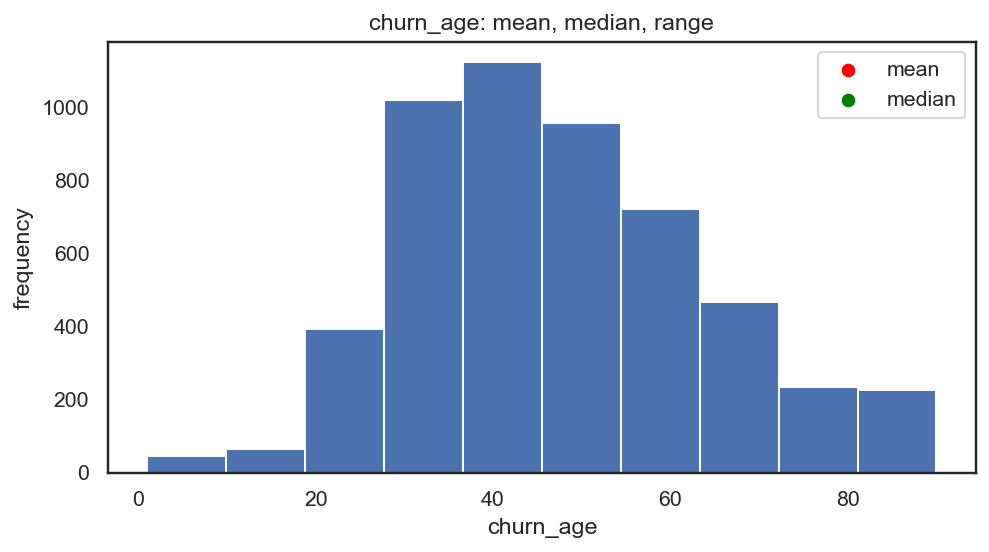

In [35]:
# setting image resolution
plt.figure(figsize=(8,4), dpi = 140)

# plotting histogram and descriptive summary
plt.scatter(churn_age.mean(), 0, label = 'mean', color ='red')
plt.scatter(churn_age.median(), 0, label = 'median', color ='green')
plt.hist(churn_age,bins=10)

# axes labels
plt.xlabel('churn_age')
plt.ylabel('frequency')
plt.title('churn_age: mean, median, range')
plt.legend()


* Mean Value is higher than the Median Value
* The peak occurs at the interval (36,45) that means highest number of customers age lie in this interval
* Most customer age between 30 and 65


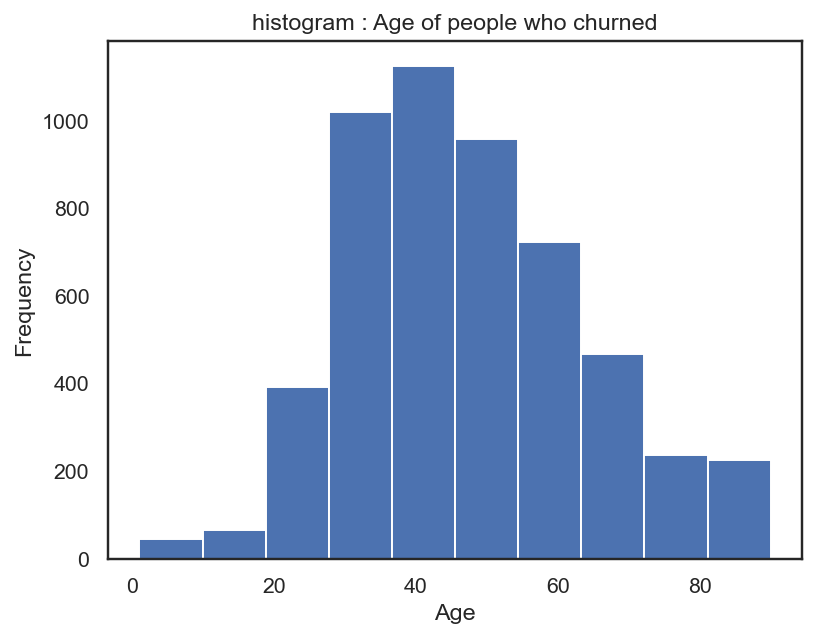

In [36]:
# plotting histogram

plt.figure(dpi = 140)
plt.hist(churn_age)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("histogram : Age of people who churned")
plt.show()

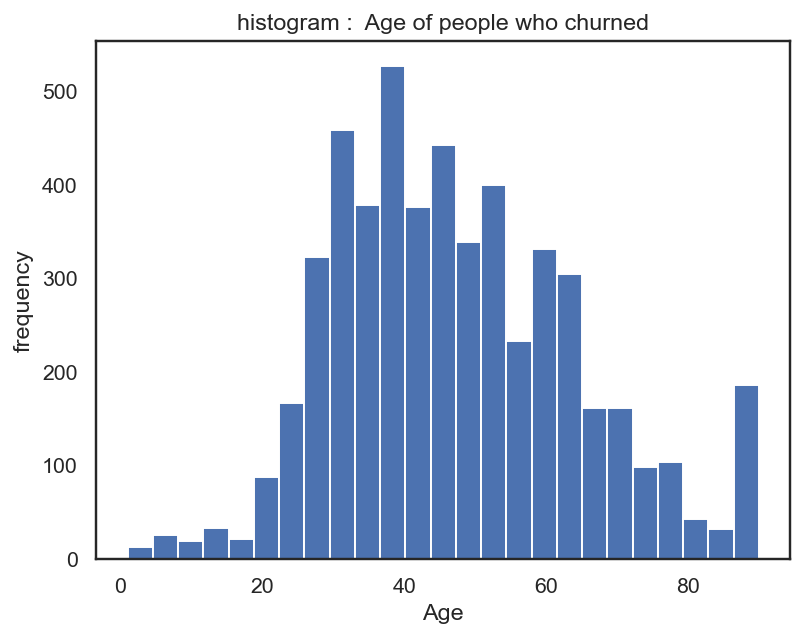

In [37]:
plt.figure(dpi = 140)
plt.hist(churn_age , bins=25)
plt.xlabel("Age")
plt.ylabel("frequency")
plt.title("histogram :  Age of people who churned")
plt.show()

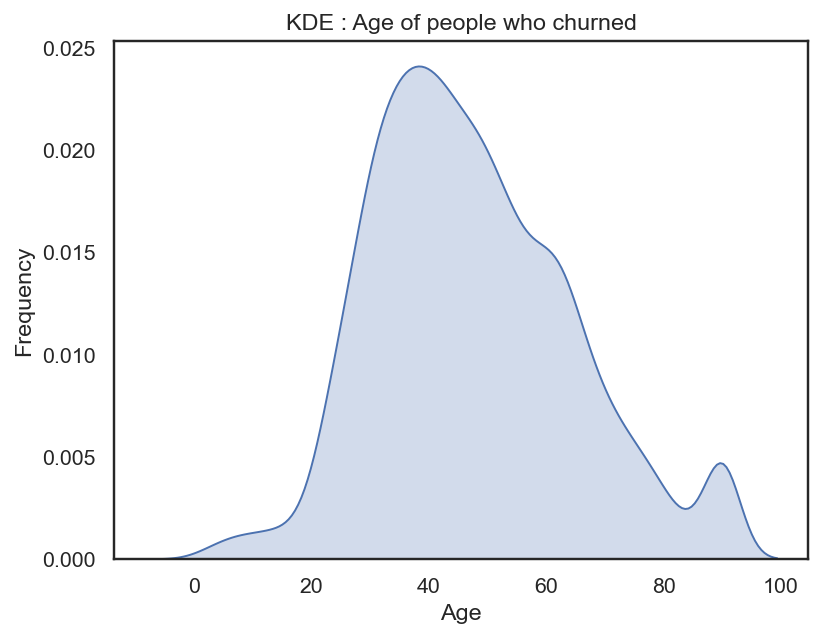

In [38]:
plt.figure(dpi = 140) # --> dpi = dots per inch
sns.kdeplot(churn_age, fill=True) # --> shade is now deprecated in favor of 'fill'
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("KDE : Age of people who churned")
plt.show()

In [39]:
# calculation points of mean, median and standard deviation

mean = churn_age.mean()
median = churn_age.median()
stdev = churn_age.std()
within_one_stdev = churn_age.mean() - churn_age.std() , churn_age.mean() + churn_age.std()

#checking
mean, median, stdev, within_one_stdev

(47.461216730038025,
 45.0,
 17.17597414675194,
 (30.285242583286085, 64.63719087678996))

* __within_one_stdev = churn_age.mean() - churn_age.std() , churn_age.mean() + churn_age.std()__
the code creates a tuple with two values:

churn_age.mean() - churn_age.std(): This calculates the lower bound of the range, which is the mean minus one standard deviation.

churn_age.mean() + churn_age.std(): This calculates the upper bound of the range, which is the mean plus one standard deviation.

The resulting tuple, within_one_stdev, contains these two values and __represents the range of ages__ that fall within one standard deviation of the mean age. This __range gives you an idea of how spread out the ages are around the mean__.

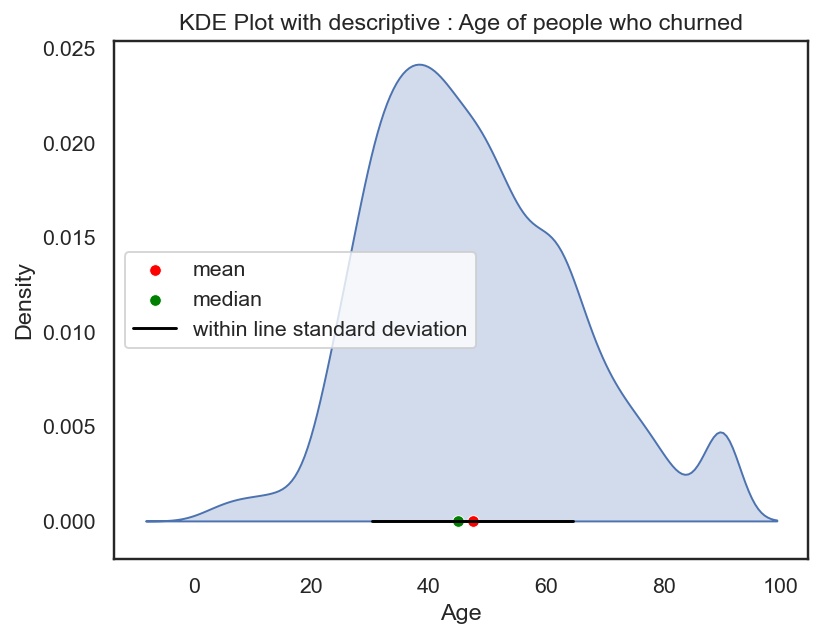

In [40]:
# plotting KDE plot with descriptives
plt.figure(dpi = 140)
sns.kdeplot(churn_age, fill=True)
sns.scatterplot(x=[mean],y=[0], color='red', label='mean')
sns.scatterplot(x=[median],y=[0], color='green', label='median')
sns.lineplot(x= within_one_stdev, y=[0,0], color='black', label='within line standard deviation')
plt.ylim(bottom= -.002)  # --> ylim() =  is used to set lower limit of y axis which  is set below zero
plt.xlabel("Age")
plt.ylabel('Density')
plt.title("KDE Plot with descriptive : Age of people who churned")
plt.show()

By setting y=[0], you ensure that these points are placed on the x-axis itself. Essentially, it means that 
__the points will be at the zero position on the y-axis, aligning them horizontally along the x-axis at their respective x-values__.

__USING PREVIOUS DATAFRAME [data]__

In [41]:
# CALCULATING POINTS OF STANDARDS DEVIATION
age = data['age']
a_mean = age.mean()
a_median = age.median()
a_stdev = age.mean() - age.std(), age.mean() + age.std()

# checking
a_mean , a_median, a_stdev

(48.208336269466564, 46.0, (30.401172896500047, 66.01549964243308))

* Mean value of age is 48.208336269466564
* Median value for age is 46.0
* Spread for first standard deviation is (30.40117289650014, 66.01549964243299)

Text(0.5, 1.0, 'KDE Plot with descriptives : Age of people')

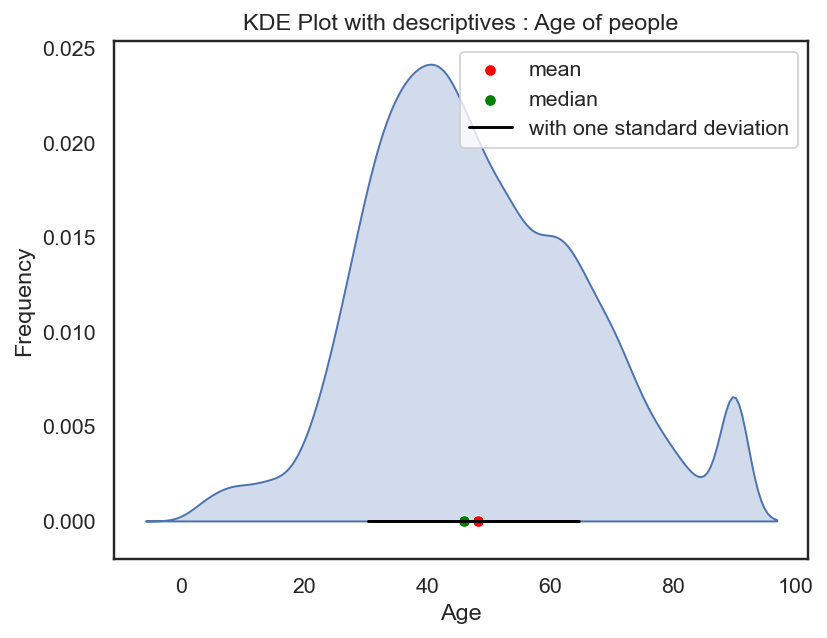

In [42]:
# plotting KDE plot with descriptives

plt.figure(dpi=140)
sns.kdeplot(age, fill=True)
sns.scatterplot(x=a_mean, y=[0], color='red', label='mean')
sns.scatterplot(x=a_median, y=[0], color='green', label='median')

sns.lineplot(x=within_one_stdev, y=[0,0], color='black', label='with one standard deviation')
plt.ylim(-.002)
plt.xlabel("Age")
plt.ylabel('Frequency')
plt.title("KDE Plot with descriptives : Age of people")
#plt.show()


* KDE indicates that age of Customers follow a distribution which is similar to __Normal Distribution__
* Suprisingly there are more than expected __Older customers__  in our dataset

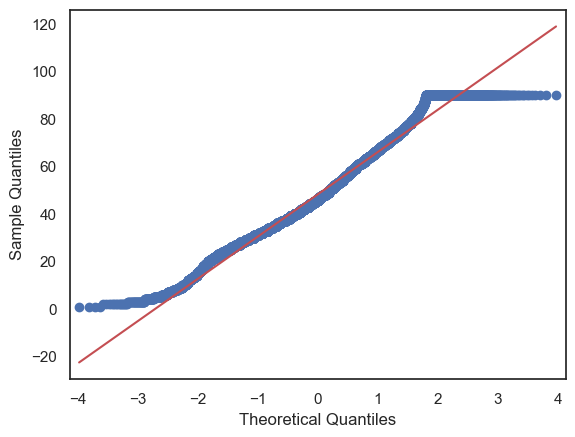

In [43]:
# qq plot explain
sm.qqplot(age, line='s')
plt.show()

* __Larger values__ are __not as large/extreme__ as expected from a Normal Distribution
* __Smaller values__ are __not as smaller/extreme__ as expected from a Normal Distribution

In [44]:
data['age'].skew()

0.33058929557517264

* __Skewness__ is around 0.33
* Age of Cusotmers follows a __Normal__ like Distribution 

In [45]:
data['age'].kurtosis()

-0.16866785691275865

* __Kurtosis Value__ is also close to Zero.
* This means tails are not as __dense__ as compared to Normal Distribution.
* There are less values available along the tails.

## Vinatge

In [46]:
# calculating measures
v_mean = data['vintage'].mean()
v_median = data['vintage'].median()
v_mode = data['vintage'].mode() 

# checking
v_mean, v_median, v_mode

(2091.1441054189277,
 2154.0,
 0    2251
 1    2260
 Name: vintage, dtype: int64)

* __Mean value__ of vintage is 2091.1441054189277
* __Median value__ for vintage is 2154.0
* __Mode value__ for  vintage is  2251 and 2260. Both of them have same frquency

In [47]:
print(data[data['vintage']==2251].shape[0])
print(data[data['vintage']==2260].shape[0])

69
69


* The frequency for 2251 and 2260 is 69
* __Both__ of them qualify to be the __mode__ value (most frequent value) for the dataset.

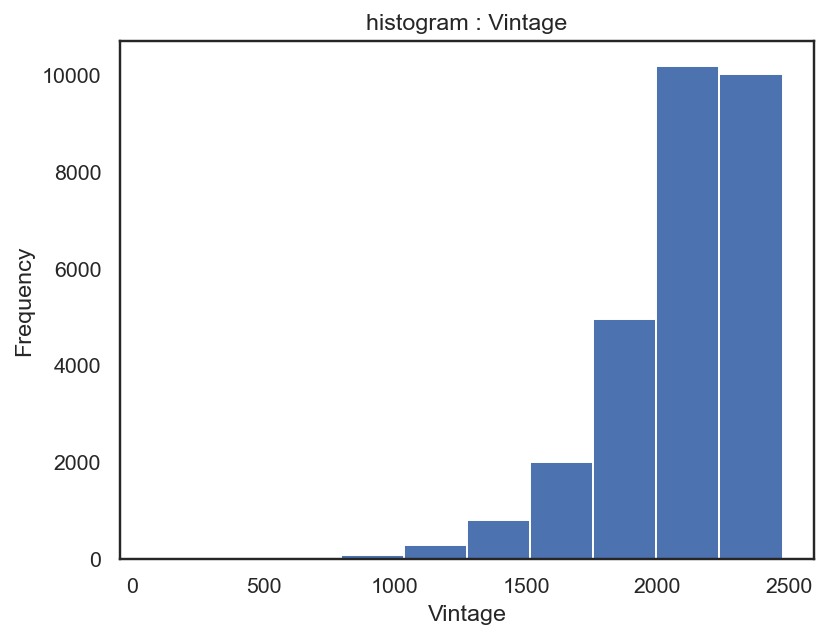

In [48]:
# plotting histogram
plt.figure(dpi = 140)
plt.hist(data['vintage'])
plt.xlabel('Vintage')
plt.ylabel('Frequency')
plt.title("histogram : Vintage")
plt.show()

* Clearly Histogram indicates that distribution is __Left Skewed__ for Vinatage.
* More customers have interaction with the bank from More days in compare to the customer who are new for the bank




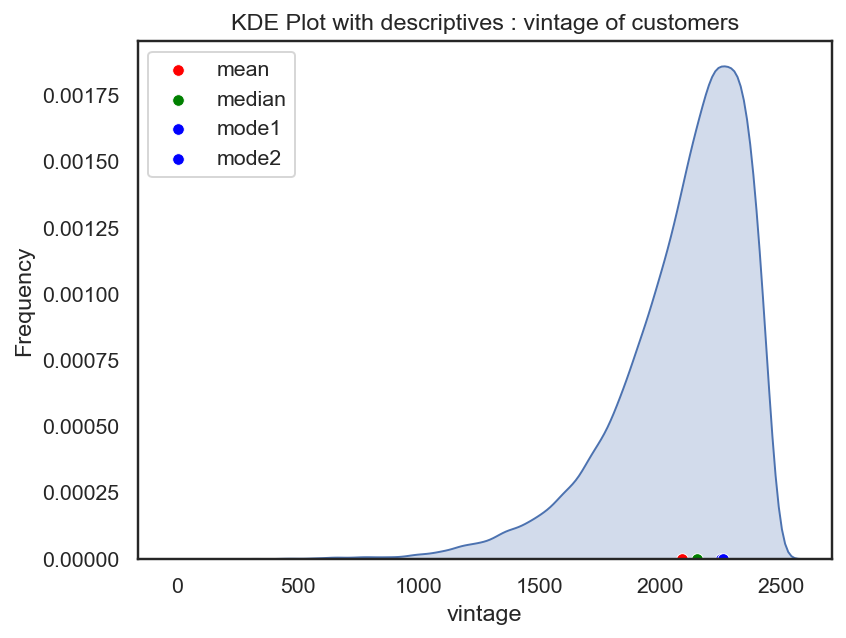

In [49]:
# plotting KDE plot with descriptives
plt.figure(dpi = 140)
sns.kdeplot(data['vintage'], fill=True)
sns.scatterplot(x=[v_mean], y=[0], color='red', label='mean')
sns.scatterplot(x=[v_median], y=[0], color='green', label='median')
sns.scatterplot(x=[v_mode[0]], y=[0], color='blue', label='mode1')
sns.scatterplot(x=[v_mode[1]], y=[0], color='blue', label='mode2')

plt.xlabel("vintage")
plt.ylabel('Frequency')
plt.title("KDE Plot with descriptives : vintage of customers")
plt.show()

* KDE indicates that Vinatge of Customers follow a distribution which is __Left Skewed__.
* __Mean and Median__ are __lower__ than the __Mode__ Value.
* tail on the __left__ side of the distribution is __longer__.

In [50]:
# explain skewness
data['vintage'].skew()

-1.3889357082821185

* __Negative Skewness__ indicates __Negatively skewed__
* __Negatively skewed__ is also known as __Left Skewed Distribution__



In [51]:
# kurtosis Positive
data['vintage'].kurtosis()

2.7234245375227926

* __Positive Kurtosis__ indicates __Leptokurtic Distribution__
* Distribution is __longer__ in compare to Normal Distribution 
* High presence of __extreme values__

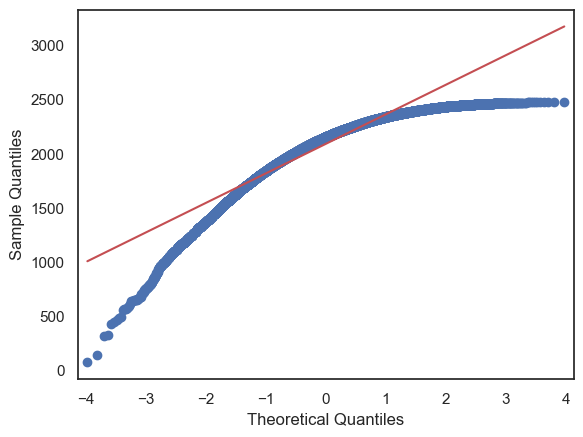

In [52]:
# qq plot explain
sm.qqplot(data['vintage'], line='s')
plt.show()

* Larger values are not as large as expected from a Normal Distribution
* Smaller values are lesser in magnitude as compared to a normal distribution

In [53]:
# distribution of gender
data['gender'].value_counts()

gender
Male      16548
Female    11309
Name: count, dtype: int64

**Number of Male Customers is greater than Number of Female Customer in our data**

In [54]:
# lets get the percentage of gender
data['gender'].value_counts()/sum(data['gender'].value_counts().values)

gender
Male      0.594034
Female    0.405966
Name: count, dtype: float64

In [55]:
# lets get thee percentage of gender
data['gender'].value_counts(normalize=True)

gender
Male      0.594034
Female    0.405966
Name: proportion, dtype: float64

**Approximately %60 Customer are Male Customer and 40% Customer are Female Customer**

In [56]:
# lets get unique value from colunm occupation
data['occupation'].nunique()

5

##### There aretotal 5 unique categories for occupation feature in our data

In [57]:
# lets grt the mode of co;unm occupation
data['occupation'].mode()

0    self_employed
Name: occupation, dtype: category
Categories (5, object): ['company', 'retired', 'salaried', 'self_employed', 'student']

* For occupation category , Most number of customer will follow 'SELF EMPLOYED' occupation.
* For occupation category, MOde id self employed which is represented bu 0 in our dataset.

In [58]:
data['occupation'].value_counts()

occupation
self_employed    17476
salaried          6704
student           2058
retired           2024
company             40
Name: count, dtype: int64

* Most customer follow Self Employed Profession in our dataset.
* Very Few Customer follow Company Profession in our dataset.

## Bernoulli

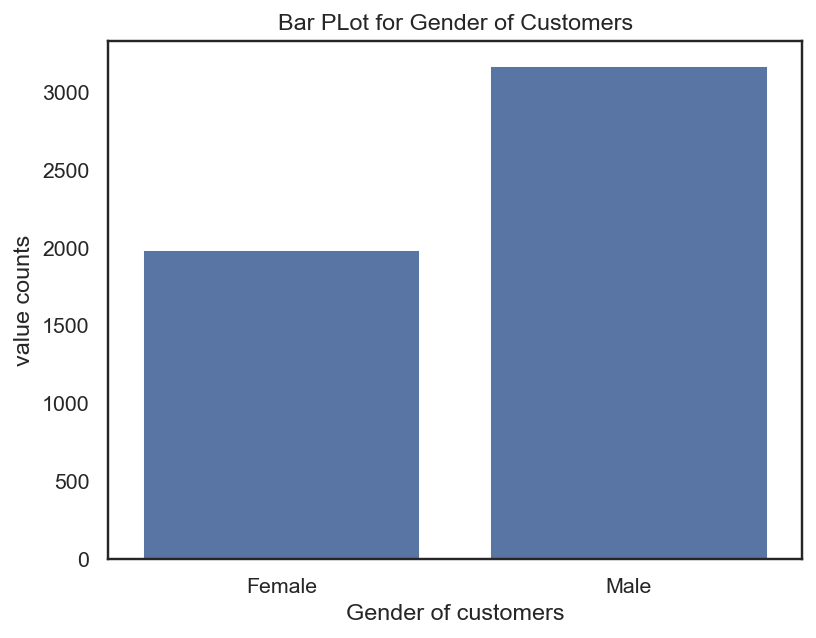

In [59]:
plt.figure(dpi = 140)
sns.barplot(x=data[data['churn']==1]['gender'].value_counts().index, y=data[data['churn']==1]['gender'].value_counts().values)
plt.xlabel('Gender of customers')
plt.ylabel('value counts')
plt.title('Bar PLot for Gender of Customers')
plt.show()

---
* .index:

This attribute returns the labels (or indices) of the Series.

For a value_counts() result, .index gives you the unique values in the Series you counted.

In your case, data[data['churn']==1]['gender'].value_counts().index returns the unique gender values of customers who churned (e.g., 'Male' and 'Female').

* .values:

This attribute returns the data (or values) stored in the Series.

For a value_counts() result, .values gives you the counts of each unique value in the Series.

In your case, data[data['churn']==1]['gender'].value_counts().values returns the count of male and female customers who churned (e.g., [120, 80] if 120 males and 80 females churned).

---

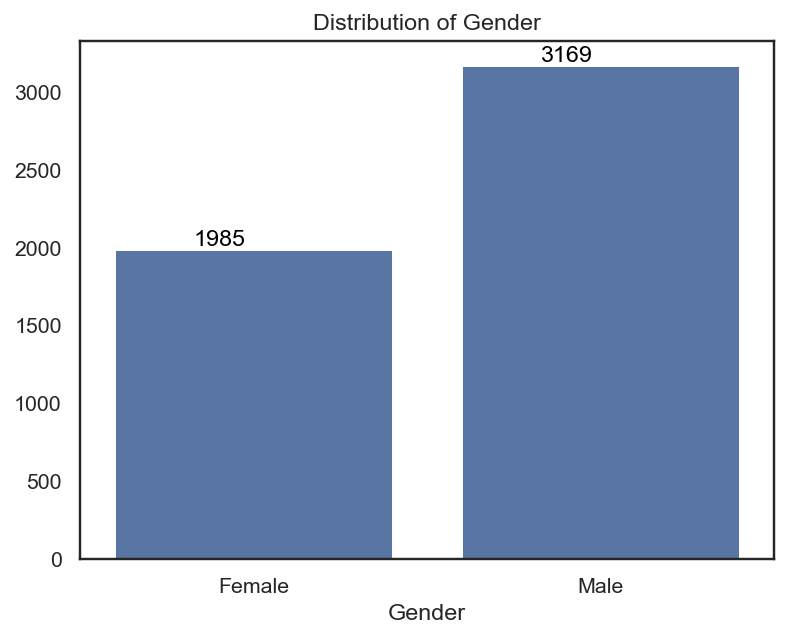

In [60]:
plt.figure(dpi = 140)
ax = sns.barplot(x=data[data['churn']==1]['gender'].value_counts().index, y=data[data['churn']==1]['gender'].value_counts().values, orient = 'v')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
for p in ax.patches:
        ax.annotate('{:1.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()),
                    ha='center', va='bottom',
                    color= 'black')
        
plt.show()

There are more Male Customer Who are churninng than the female customer who are churning.

---
* (p.get_x()+0.3, p.get_height()) 
    specifies the coordinates where the annotation (text) will be placed.

* p.get_x()
            returns the x-coordinate (position) of the bar.

* p.get_x()+0.3 
            adjusts the x-coordinate slightly to position the annotation near the center of the bar. The value 0.3 is chosen to center the text horizontally within the bar.

* p.get_height() 
            is the y-coordinate of the annotation, placing it at the top of the bar.

*  '{:1.0f}' is a format string. It specifies that the value should be formatted as a floating-point number with 1 digit before the decimal point and no digits after the decimal point.

* p.get_height() returns the height of the bar (i.e., the y-value or count of the bar).

* .format(p.get_height()) formats the height as an integer using the format string. So, if the    height of the bar is 120.0, it will be formatted as '120'.



---

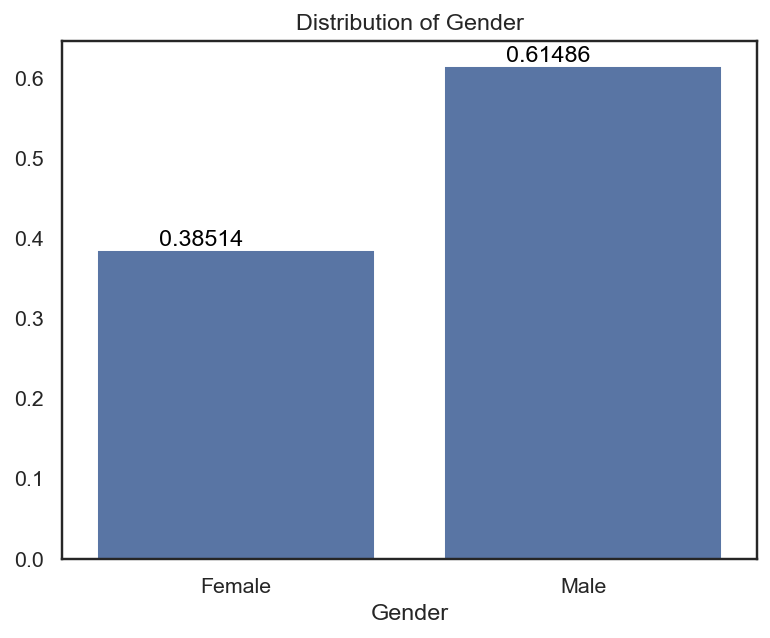

In [61]:
plt.figure(dpi = 140)
ax = sns.barplot(x=data[data['churn']==1]['gender'].value_counts().index , y = data[data['churn']==1]['gender'].value_counts(normalize = True).values,orient ='v')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
for p in ax.patches:
    ax.annotate('{:1.5f}'.format(p.get_height()),(p.get_x()+0.3, p.get_height()),
                 ha='center' , va='bottom',
                 color='black')
plt.show()

* Around 61% of Churning Customers are Male Customers in our Dataset
* Around 39% of Churning Customers are female Customers in our Dataset

# Categorical

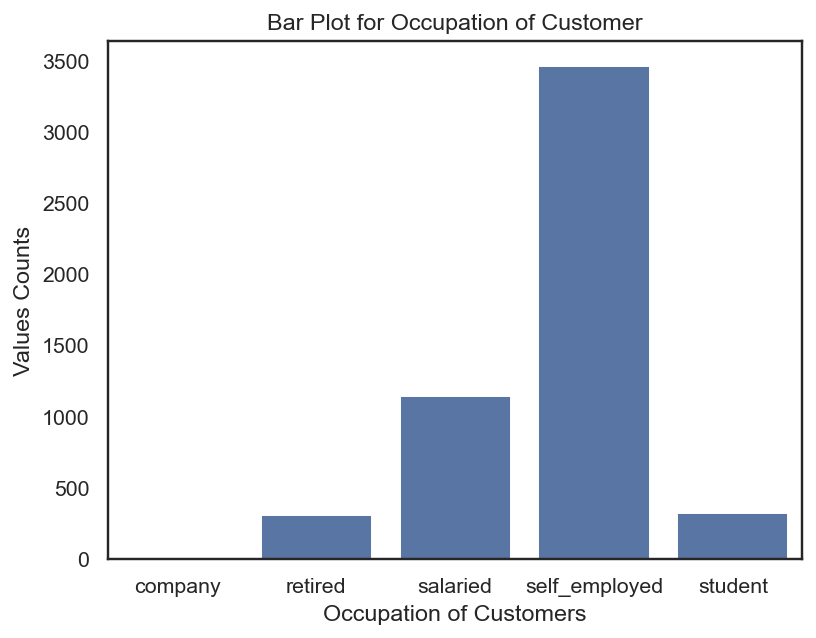

In [62]:
plt.figure(dpi = 140)
sns.barplot(x = data[data['churn']==1]['occupation'].value_counts().index , y = data[data['churn']==1]['occupation'].value_counts().values)
plt.title("Bar Plot for Occupation of Customer")
plt.xlabel('Occupation of Customers')
plt.ylabel('Values Counts')
plt.show()

* Highest Number of Customers are churning from self employed profession followed by salaried.
* Number of Customers who are churning from Student and retired category are close to each other.
* Company as a profession has the least number of customers who are churning

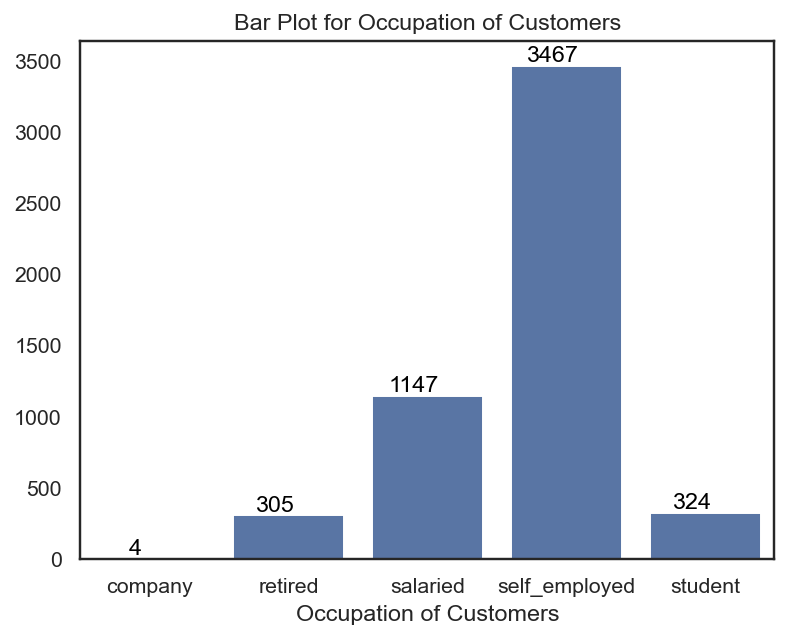

In [63]:
plt.figure(dpi = 140)
ax = sns.barplot(x=data[data['churn']==1]['occupation'].value_counts().index, y = data[data['churn']==1]['occupation'].value_counts().values , orient ='v')
for p in ax.patches:
    ax.annotate('{:1.0f}'.format(p.get_height()) ,( p.get_x()+0.3 , p.get_height()),
    ha='center' , va='bottom',
    color='black')
plt.xlabel("Occupation of Customers")
plt.title("Bar Plot for Occupation of Customers")
plt.show()

* 3467 Customers are churning from self employed category
* 1147 customers are churning from salaried category
* 324 and 305 customers are churning from student and retired category
* Only 4 customers are churning from company profession

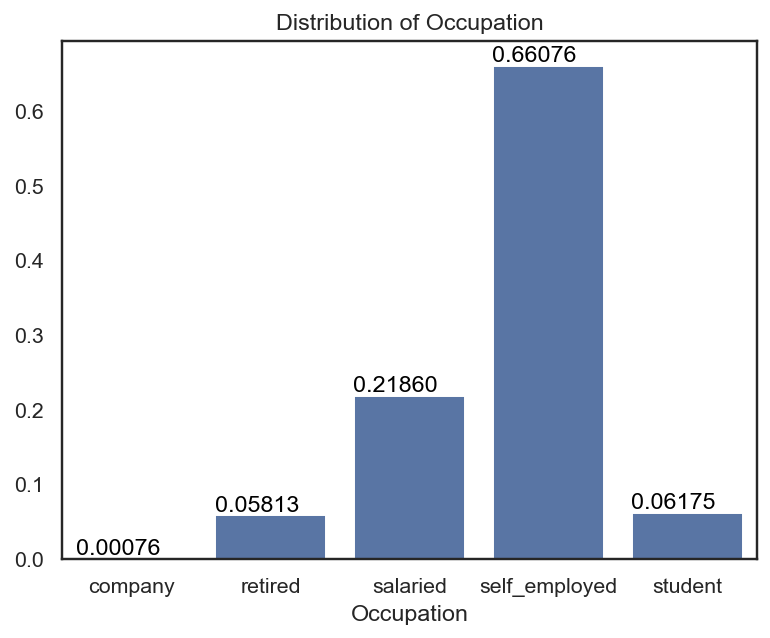

In [64]:
plt.figure(dpi = 140)
ax = sns.barplot(x = data[data['churn']==1]['occupation'].value_counts().index, y = data[data['churn']==1]['occupation'].value_counts(normalize = True).values, orient='v')
plt.title('Distribution of Occupation')
plt.xlabel('Occupation')
for p in ax.patches:
    ax.annotate('{:1.5f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()),
              ha='center', va='bottom',
              color='black')
plt.show()

* Almost 66 % of the customers who are churning belong to self employed profession
* Followed by 21% of customers who are churning belong to salaried profession

* **normalize=True** is used within the value_counts() function to calculate the proportion (or frequency) of each unique value instead of the raw counts. When normalize=True is applied, the result is normalized to 1, meaning it returns the relative frequency of each unique value as a fraction of the total.
* When normalize=True is used, value_counts() will return the proportion of each unique value. For example, if there are 10 occurrences of 'A', 20 occurrences of 'B', and 30 occurrences of 'C' in a total of 60 entries, the function will return 0.1667 (10/60), 0.3333 (20/60), and 0.5000 (30/60), respectively.

In [65]:
data.select_dtypes(include=['int64','float64','Int64']).dtypes

customer_id                         int64
vintage                             int64
age                                 int64
dependents                          Int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
doy_ls_tran                       float64
moy_ls_tran                       float64
dow_ls_tran                       float64
dtype: object

In [66]:
# seggregating variables into groups
customer_details = ['customer_id','age','vintage']
current_month = ['current_balance','current_month_credit','current_month_debit','current_month_balance']
previous_month = ['previous_month_end_balance','previous_month_credit','previous_month_debit','previous_month_balance']
previous_quarters = ['average_monthly_balance_prevQ','average_monthly_balance_prevQ2']
transaction_date = ['doy_ls_tran','woy_ls_tran','moy_ls_tran','dow_ls_tran']

In [67]:
# custom function for easy and efficient analysis of numerical univariate

def UVA_numeric(data, var_group):
    ''' 
    Univariate_Analysis_numeric
    takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

    Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
    '''

    size = len(var_group)
    plt.figure(figsize = (7*size,4), dpi = 100)

    #looping for each variable
    for j,i in enumerate(var_group):
    
    # calculating descriptives of variable
        mini = round(data[i].min(), 2)
        maxi = round(data[i].max(), 2)
        ran = round(data[i].max()-data[i].min(), 2)
        mean = round(data[i].mean(), 2)
        median = round(data[i].median(), 2)
        st_dev = round(data[i].std(), 2)
        skew = round(data[i].skew(), 2)
        kurt = round(data[i].kurtosis(), 2)

        # calculating points for range of within one standard deviation
        points = round(mean-st_dev, 2), round(mean+st_dev, 2)

        #Plotting the variable with every information, can change marker size in scatterplot(i.e. s=60)
        plt.subplot(1,size,j+1)
        sns.kdeplot(x=data[i], fill=True)
        sns.lineplot(x=points, y=[0,0], color = 'black', label = "within 1 std_dev")
        sns.scatterplot(x=[mini,maxi], y=[0,0], color = 'orange', label = f"min&max={mini}&{maxi}")
        sns.scatterplot(x=[mean], y=[0], color = 'red', label = f"mean={mean}")
        sns.scatterplot(x=[median], y=[0], color = 'blue', label = f"median={median}")
        plt.xlabel('{}'.format(i), fontsize = 20)
        plt.ylabel('density')
        plt.title(f'within 1 std_dev={points[0]} to {points[1]};kurtosis={kurt};\n skew = {skew};range = {ran}')



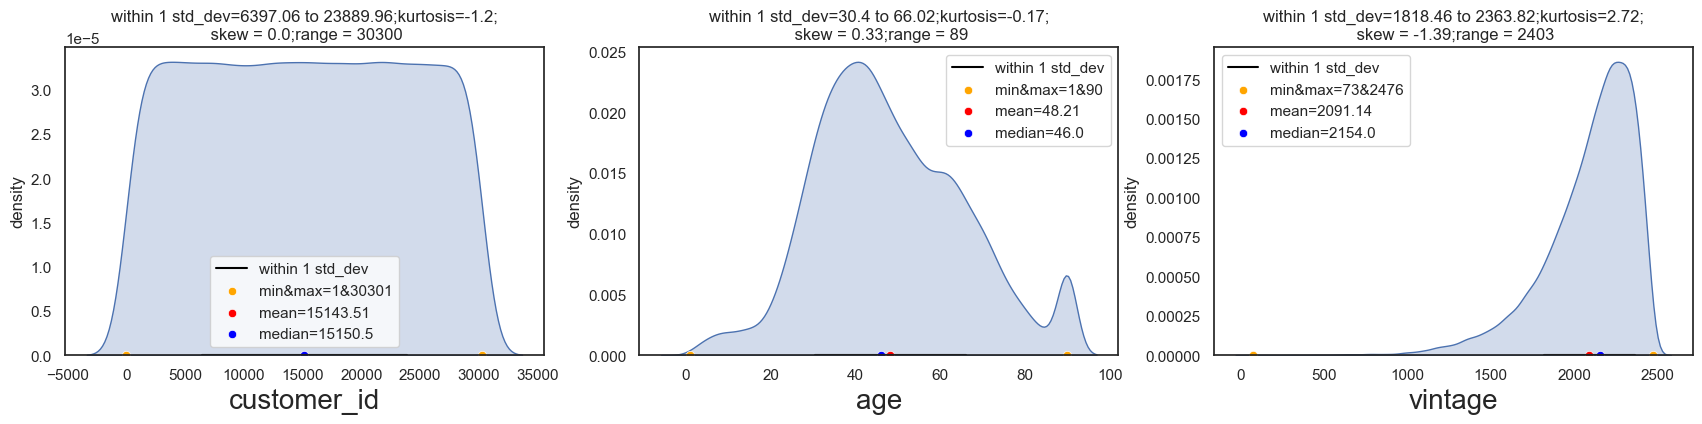

In [68]:
UVA_numeric(data,customer_details)

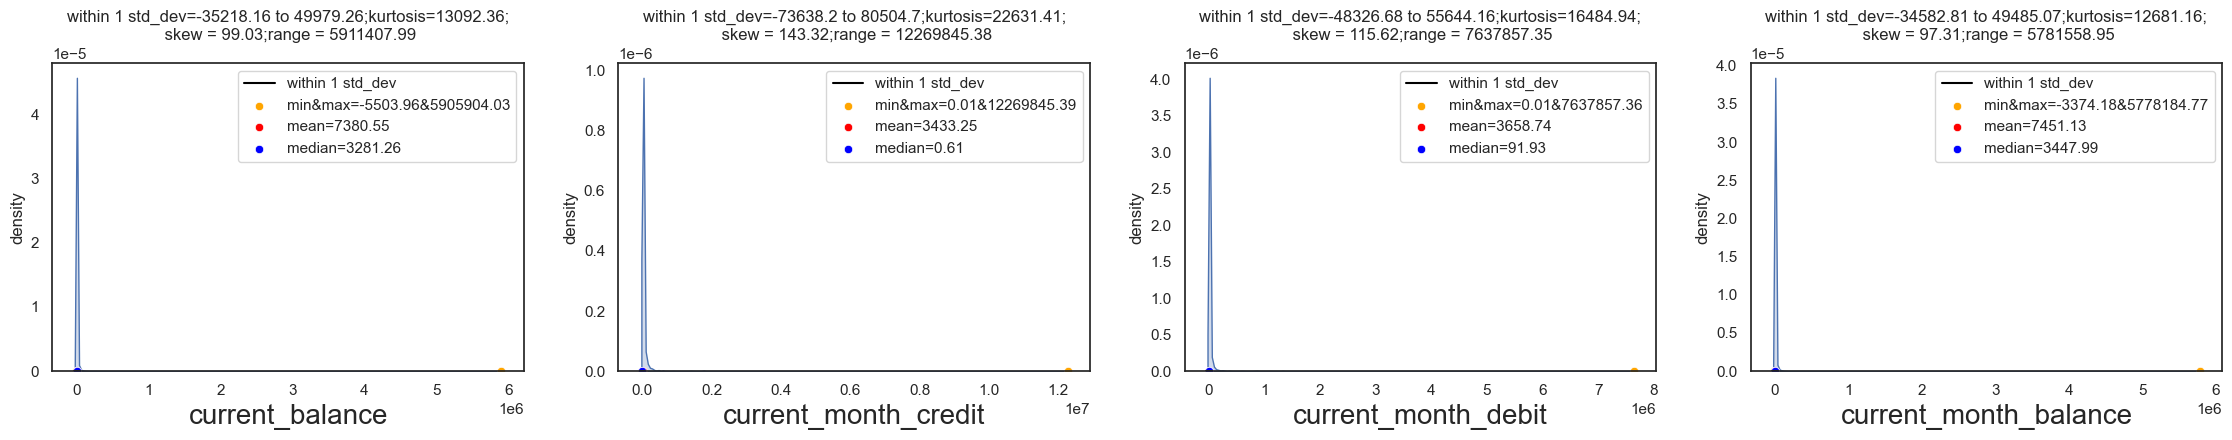

In [69]:
UVA_numeric(data,current_month)

In [70]:
# standard deviation factor
factor = 3

# copying current_month
cm_data = data[current_month]

# filtering using standard deviation (not considering obseravtions > mean + factor*standard deviation)
cm_data = cm_data[cm_data['current_balance'] < cm_data['current_balance'].mean() + factor*cm_data['current_balance'].std()]
cm_data = cm_data[cm_data['current_month_credit'] < cm_data['current_month_credit'].mean() + factor*cm_data['current_month_credit'].std()]
cm_data = cm_data[cm_data['current_month_debit'] < cm_data['current_month_debit'].mean() + factor*cm_data['current_month_debit'].std()]
cm_data = cm_data[cm_data['current_month_balance'] < cm_data['current_month_balance'].mean() + factor*cm_data['current_month_balance'].std()]

# checking how many points removed
len(data), len(cm_data)

(28382, 27425)

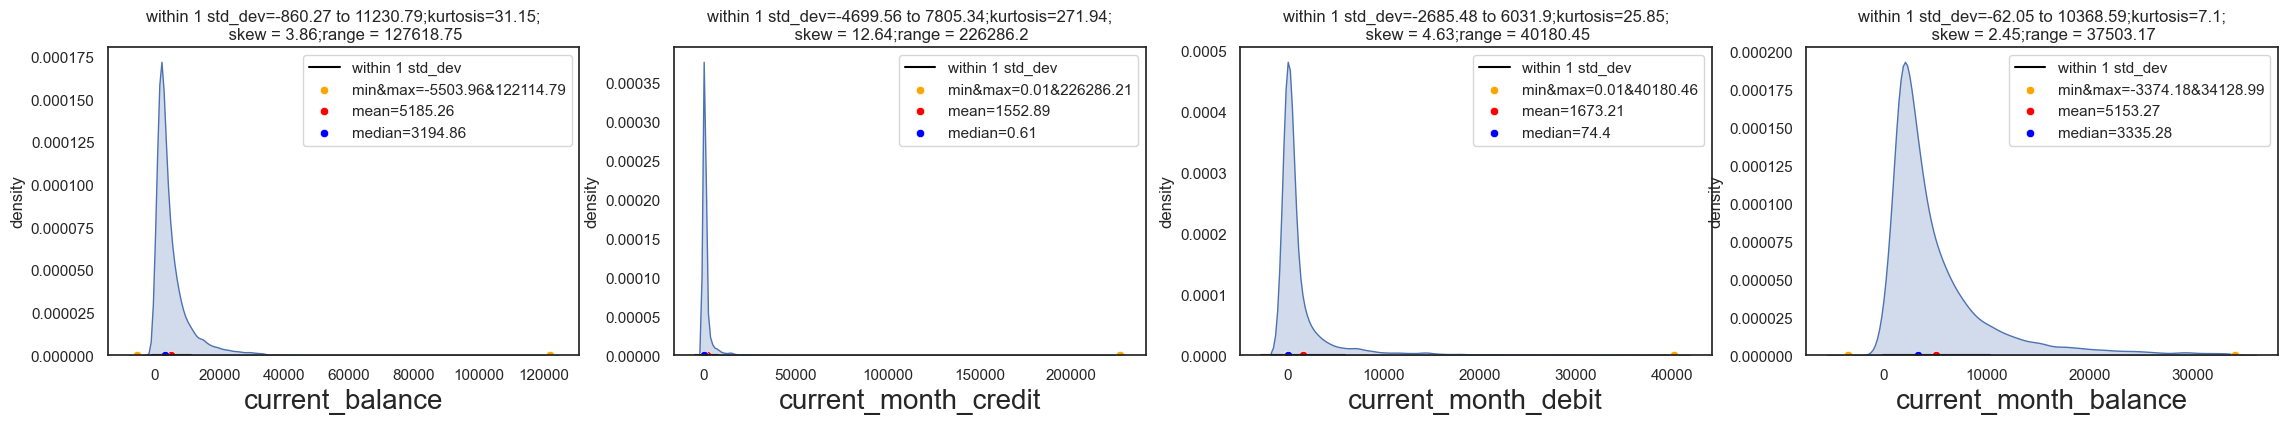

In [71]:
UVA_numeric(cm_data,current_month)

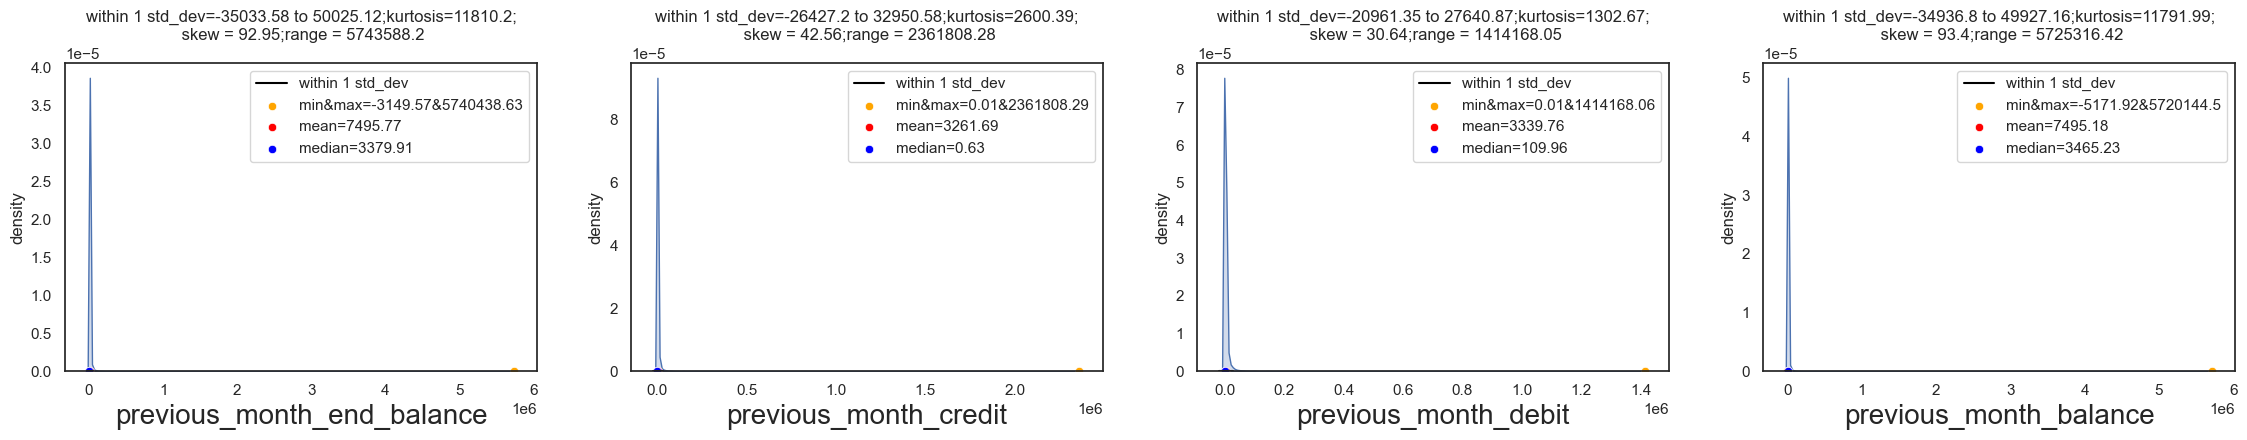

In [72]:
UVA_numeric(data, previous_month)

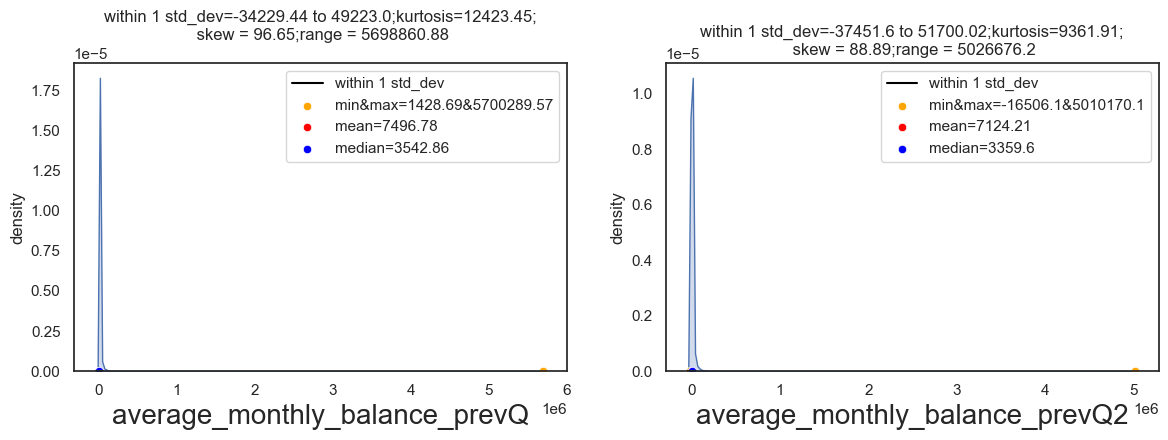

In [73]:
UVA_numeric(data, previous_quarters)

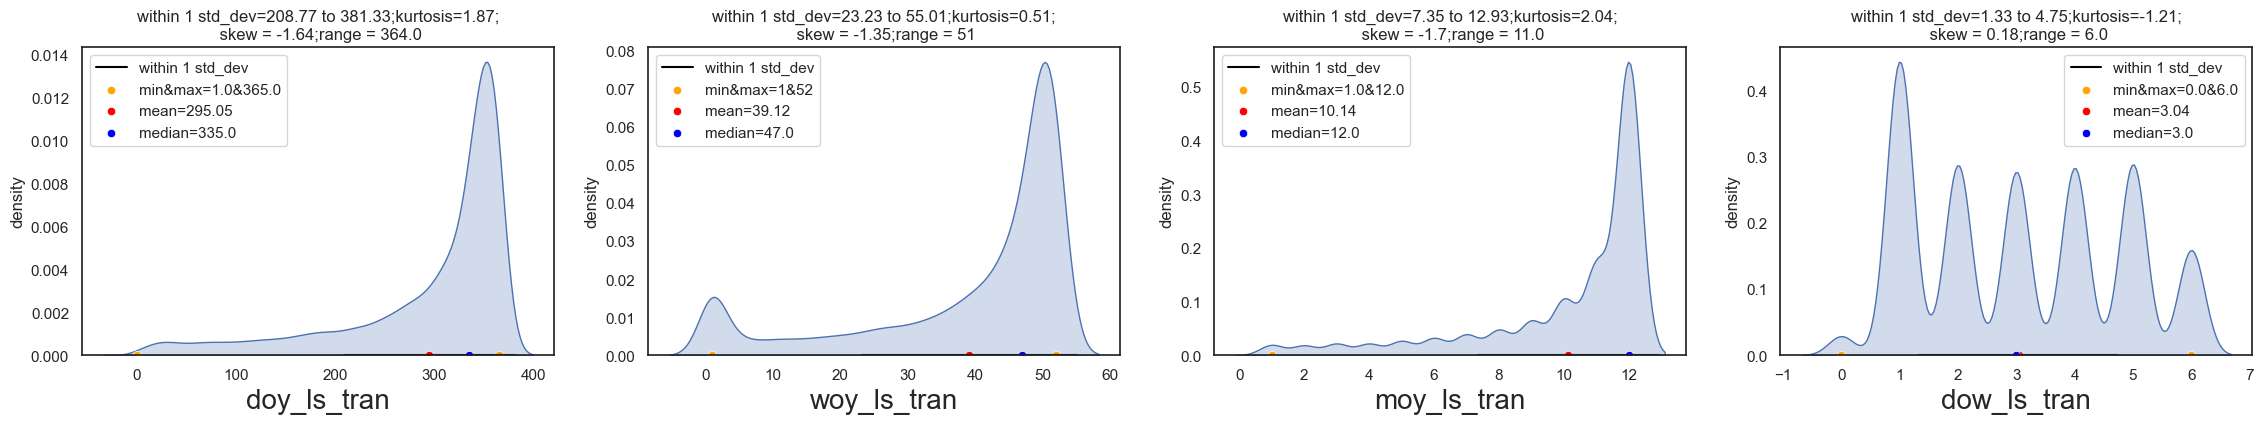

In [74]:
UVA_numeric(data, transaction_date)

In [75]:
data.select_dtypes(exclude=['int64','float64','Int64']).dtypes

gender                  category
occupation              category
city                    category
customer_nw_category    category
branch_code             category
churn                   category
woy_ls_tran               UInt32
dtype: object

In [76]:
def UVA_category(data, var_group):

  '''
  Univariate_Analysis_categorical
  takes a group of variables (category) and plot/print all the value_counts and barplot.
  '''
  # setting figure_size
  size = len(var_group)
  plt.figure(figsize = (7*size,5), dpi = 100)

  # for every variable
  for j,i in enumerate(var_group):
    norm_count = data[i].value_counts(normalize = True)
    n_uni = data[i].nunique()

  #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.barplot(x = norm_count, y = norm_count.index , order = norm_count.index)
    plt.xlabel('fraction/percent', fontsize = 20)
    plt.ylabel('{}'.format(i), fontsize = 20)
    plt.title('n_uniques = {} \n value counts \n {};'.format(n_uni,norm_count))

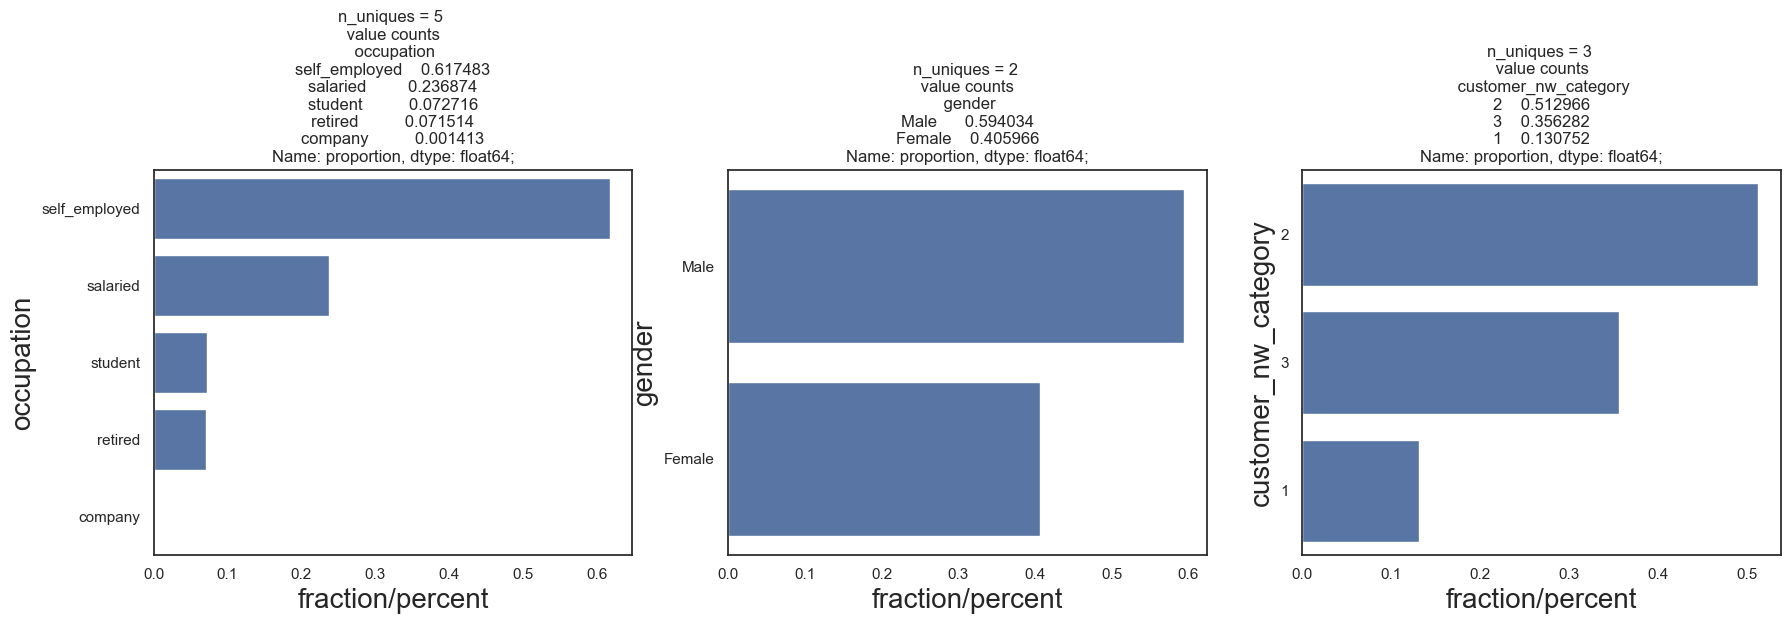

In [77]:
UVA_category(data,['occupation','gender','customer_nw_category'])

Text(0, 0.5, 'fraction/percent')

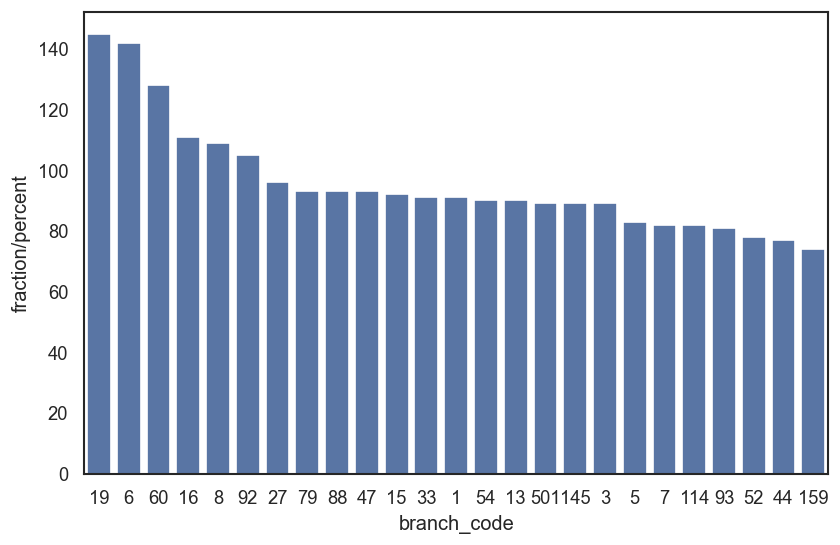

In [78]:
# plotting 'branch code'
plt.figure(figsize = (8,5), dpi = 120)
branch_count = data['branch_code'].value_counts()[:25]
sns.barplot(x=branch_count.index, y=branch_count, order = branch_count.index)
plt.xlabel('branch_code')
plt.ylabel('fraction/percent')

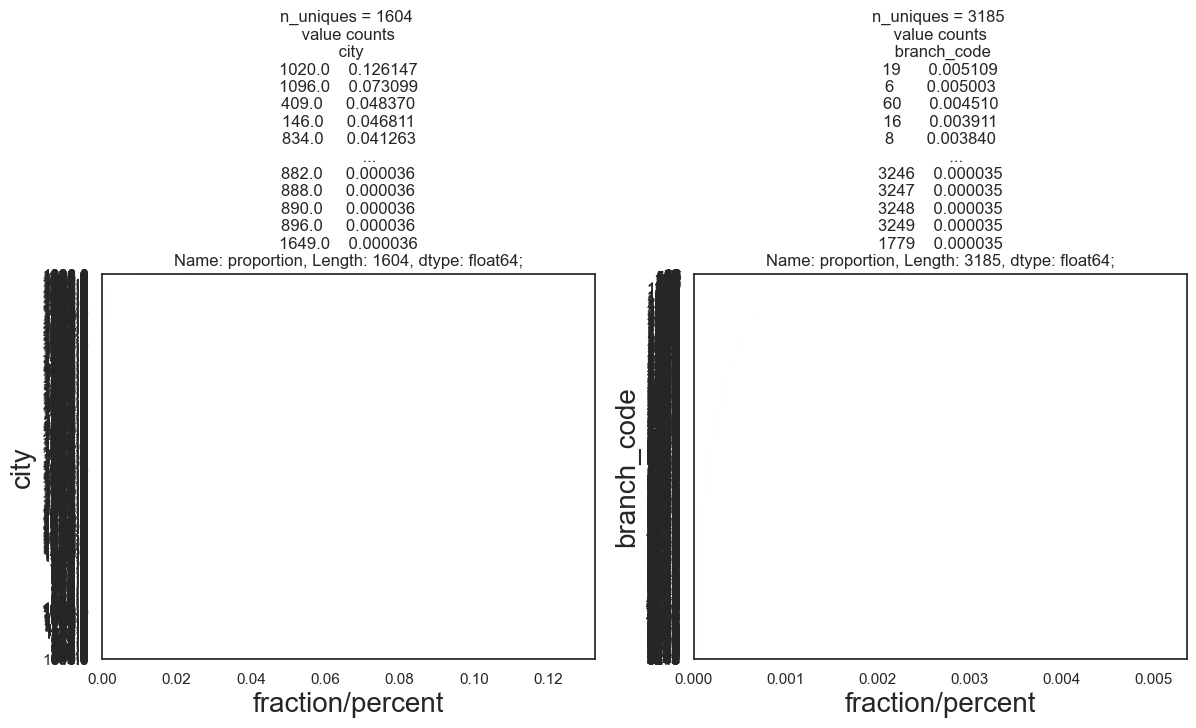

In [79]:
UVA_category(data,['city','branch_code'])

---
 * UVA_category(data,['city','branch_code',], max_categories = 15)
 * UVA_category(data,['city','branch_code'])

---

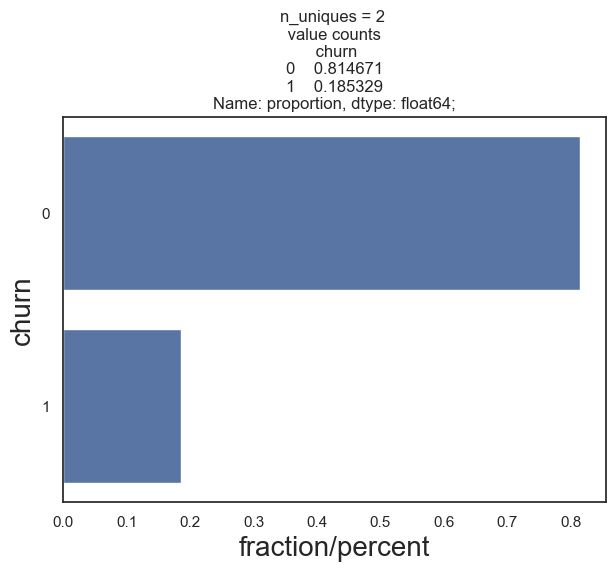

In [80]:
UVA_category(data,['churn'])

 #### * value_counts :
function returns object containing counts of unique values and can be used to print the frequency table for a varible in python.

In [81]:
data.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
doy_ls_tran                       3223
woy_ls_tran                       3223
moy_ls_tran                       3223
dow_ls_tran                       3223
dtype: int64

In [82]:
population=data['vintage']

In [83]:
population = pd.DataFrame(population)

array([[<Axes: title={'center': 'vintage'}>]], dtype=object)

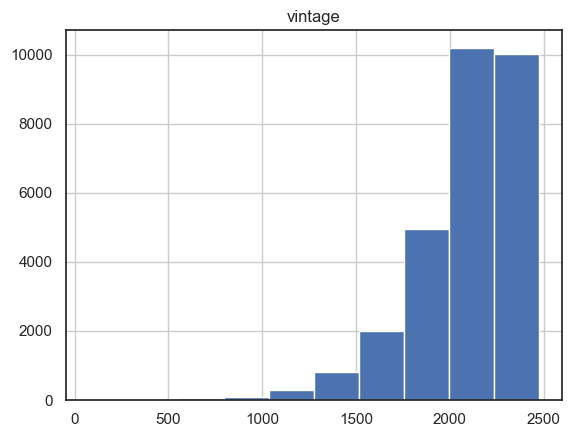

In [84]:
population.hist(bins=10)

In [85]:
population['vintage'].mean()

2091.1441054189277

In [86]:
#create a list
sampled_means = []

# for 1000 time,
for i in range(0,1000):
    # Take a random smaple of 100 rows from the popelation , take the mean of those rows , append to sample_means
    sampled_means.append(population.sample(n=100).mean().values[0])

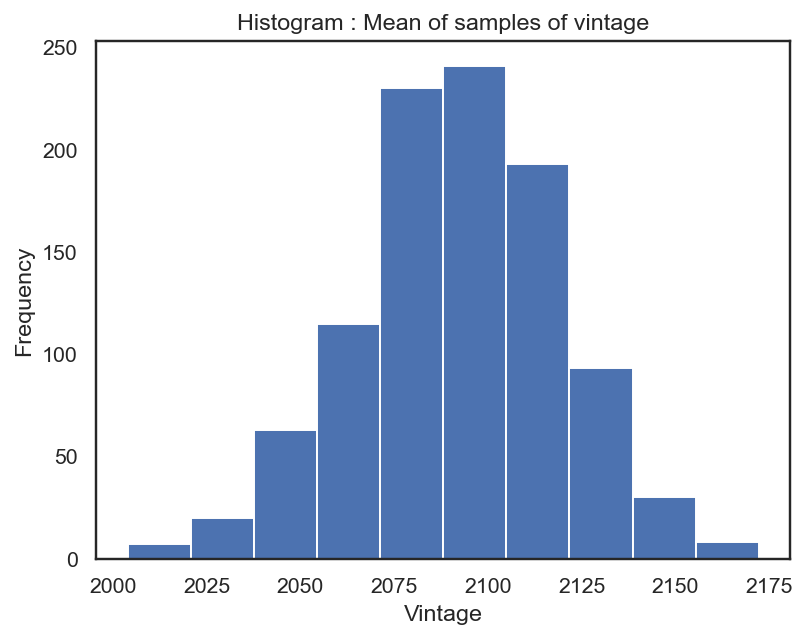

In [87]:
# plotting histogram
plt.figure(dpi = 140)
plt.hist(sampled_means)
plt.xlabel('Vintage')
plt.ylabel('Frequency')
plt.title('Histogram : Mean of samples of vintage')
plt.show()

* 100 Samples of 100 datapoints were taken 
* Mean of the random samples actully follow the Normal Distribution
* Central Limit Theorem  can be verified by using KDE as well 

In [88]:
# view the mean of the sampled_means
pd.Series(sampled_means).mean()

2092.17212

In [89]:
# sunract Mean Sample Mean From True Population Mean
error = population['vintage'].mean() - pd.Series(sampled_means).mean()

# print
print('The Mean Sample Mean is only %f different the True Population mean!' % error)

The Mean Sample Mean is only -1.028015 different the True Population mean!


In [90]:
def UVA_outlier(data, var_group, include_outlier = True):
  '''
  Univariate_Analysis_outlier:
  takes a group odeff variables (INTEGER and FLOAT) and plot/print barplot and descriptives\n
  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it \n\n

  data : dataframe from which to plot from\n
  var_group : {list} type Group of Continuous variables\n
  include_outlier : {bool} whether to include outliers or not, default = True\n
  '''

  size = len(var_group)
  plt.figure(figsize = (7*size,4), dpi = 100)
  
  #looping for each variable
  for j,i in enumerate(var_group):
    
    # calculating descriptives of variable
    quant25 = data[i].quantile(0.25)
    quant75 = data[i].quantile(0.75)
    IQR = quant75 - quant25
    med = data[i].median()
    whis_low = med-(1.5*IQR)
    whis_high = med+(1.5*IQR)

    # Calculating Number of Outliers
    outlier_high = len(data[i][data[i]>whis_high])
    outlier_low = len(data[i][data[i]<whis_low])

    if include_outlier == True:
      print(include_outlier)
      #Plotting the variable with every information
      plt.subplot(1,size,j+1)
      sns.boxplot(data[i], orient="v")
      plt.ylabel('{}'.format(i))
      plt.title('With Outliers\nIQR = {}; Median = {} \n 2nd,3rd  quartile = {};\n Outlier (low/high) = {} \n'.format(
                                                                                                   round(IQR,2),
                                                                                                   round(med,2),
                                                                                                   (round(quant25,2),round(quant75,2)),
                                                                                                   (outlier_low,outlier_high)
                                                                                                   ))
      
    else:
      # replacing outliers with max/min whisker
      data2 = data[var_group][:]
      data2[i][data2[i]>whis_high] = whis_high+1
      data2[i][data2[i]<whis_low] = whis_low-1
      
      # plotting without outliers
      plt.subplot(1,size,j+1)
      sns.boxplot(data2[i], orient="v")
      plt.ylabel('{}'.format(i))
      plt.title('Without Outliers\nIQR = {}; Median = {} \n 2nd,3rd  quartile = {};\n Outlier (low/high) = {} \n'.format(
                                                                                                   round(IQR,2),
                                                                                                   round(med,2),
                                                                                                   (round(quant25,2),round(quant75,2)),
                                                                                                   (outlier_low,outlier_high)
                                                                                                   ))

True
True
True
True


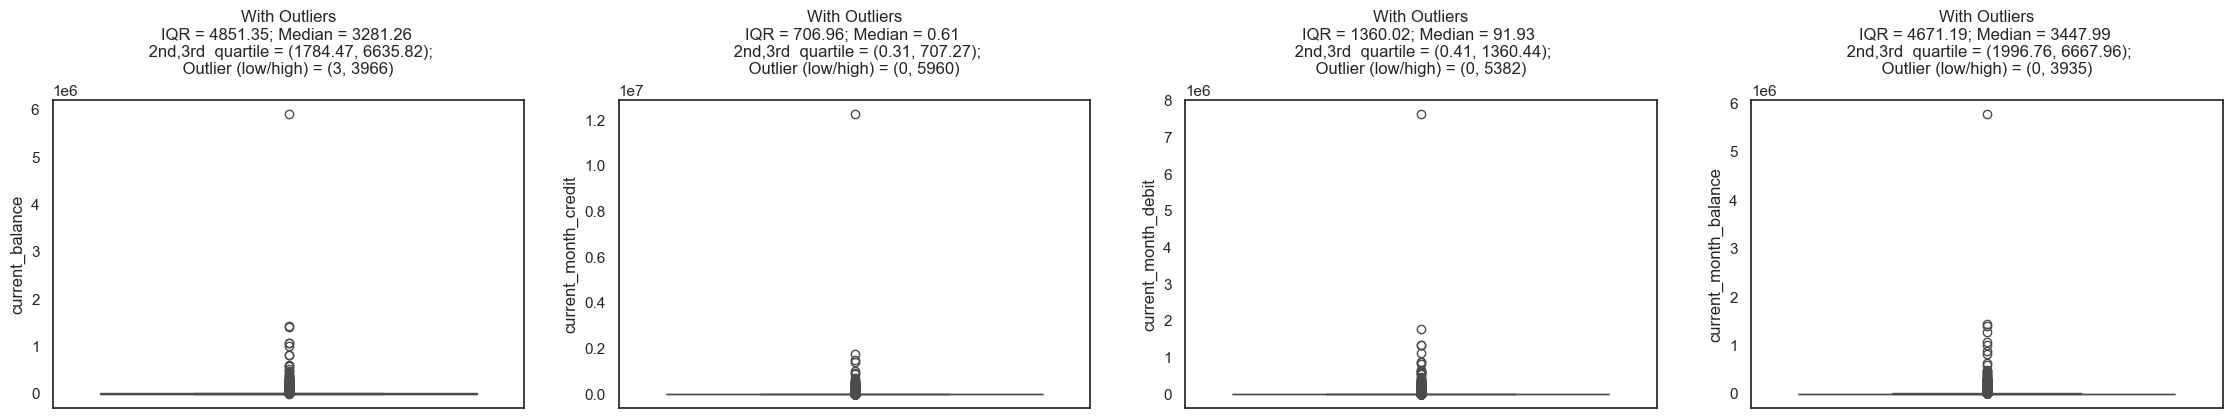

In [91]:
UVA_outlier(data, current_month)

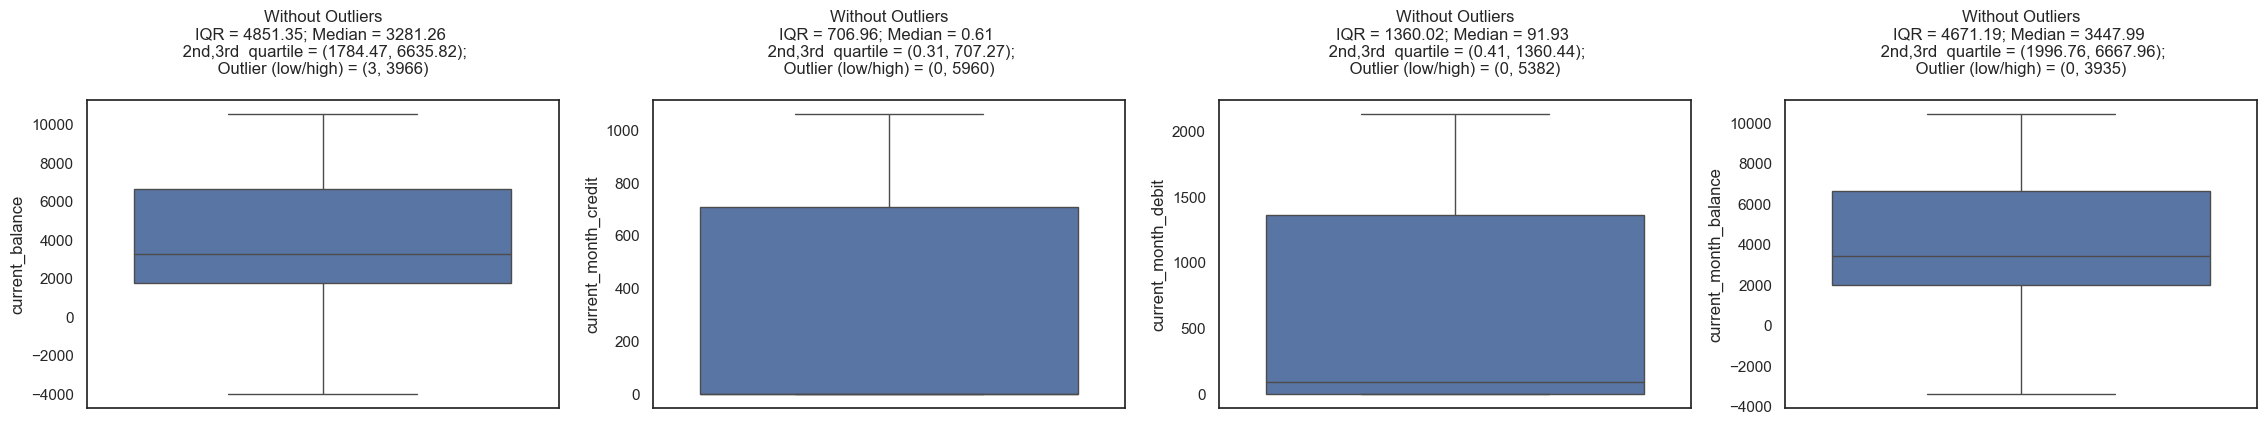

In [92]:
UVA_outlier(data, current_month,include_outlier = False)

True
True
True
True


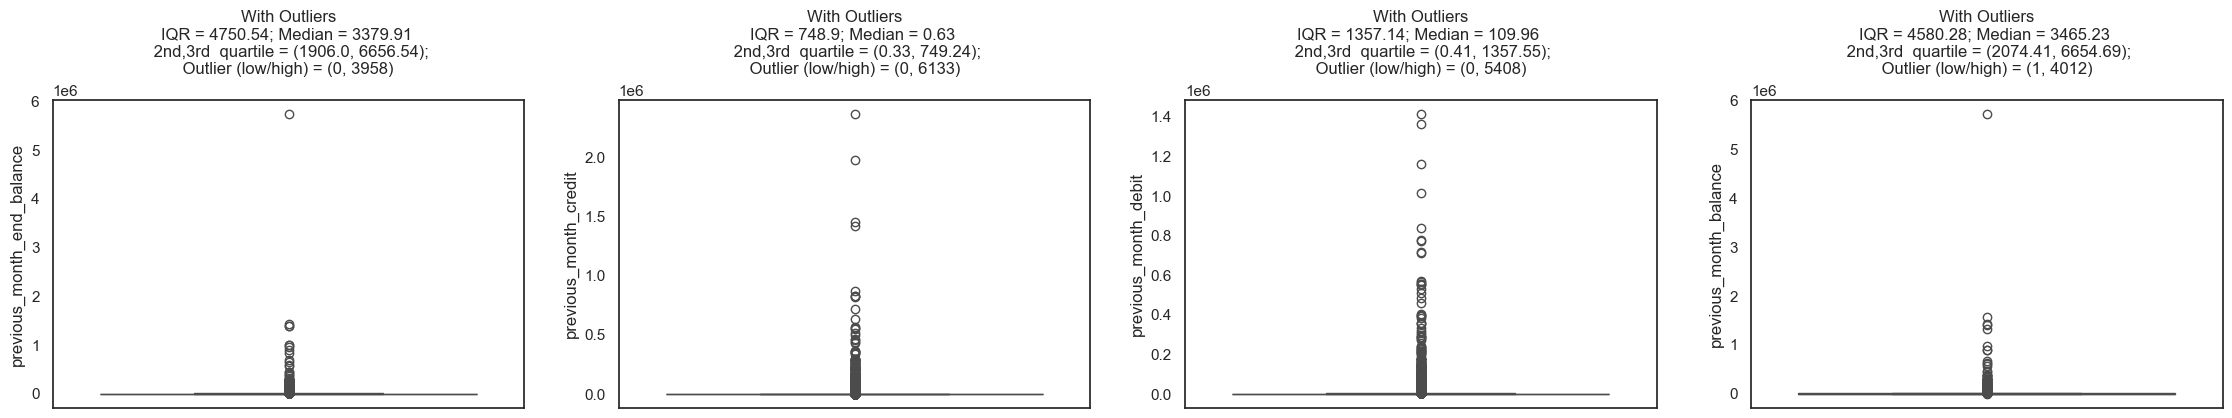

In [93]:
UVA_outlier(data, previous_month)

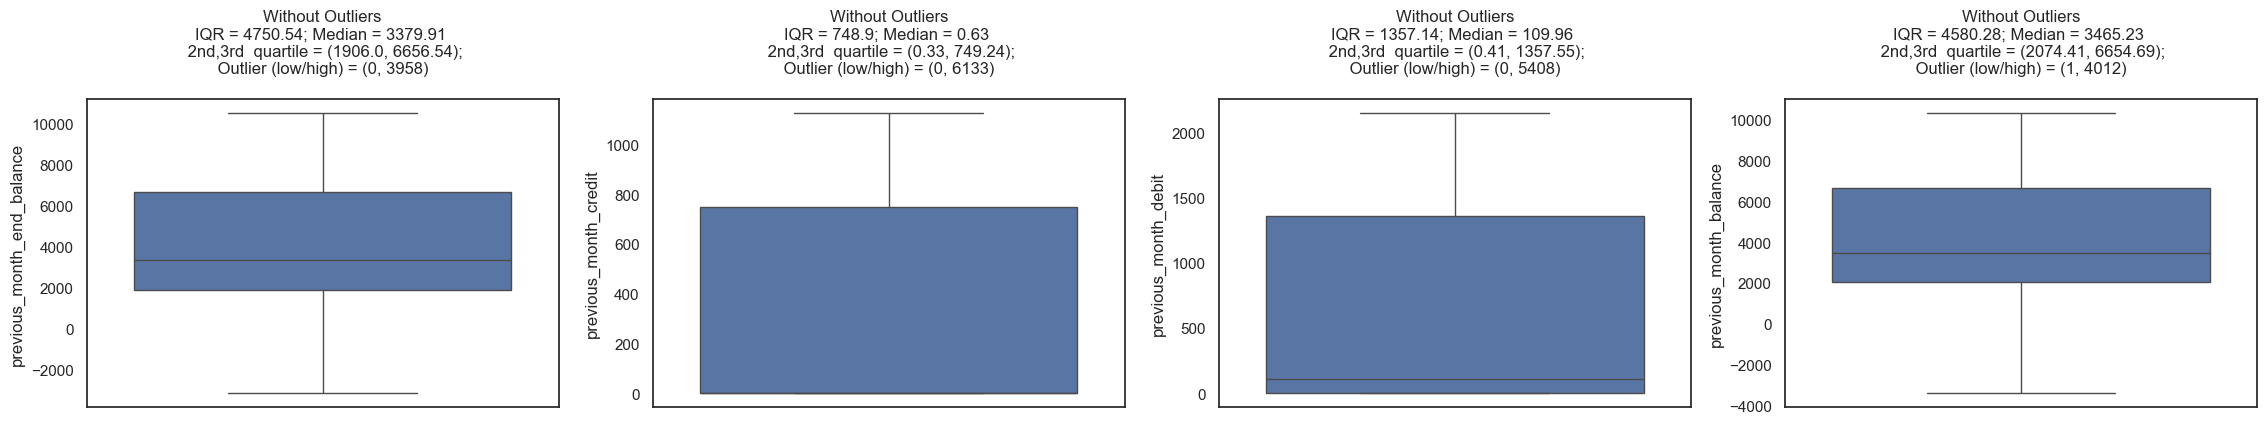

In [94]:
UVA_outlier(data, previous_month, include_outlier = False)

True
True


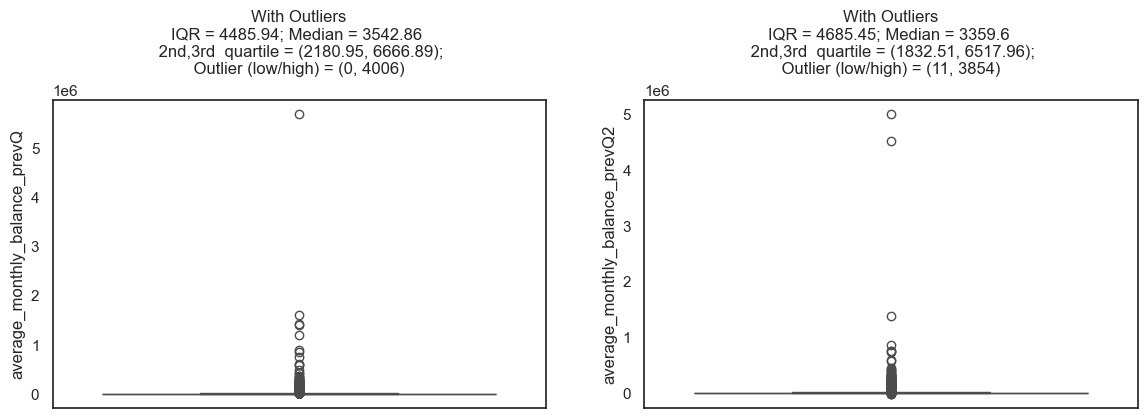

In [95]:
UVA_outlier(data, previous_quarters)

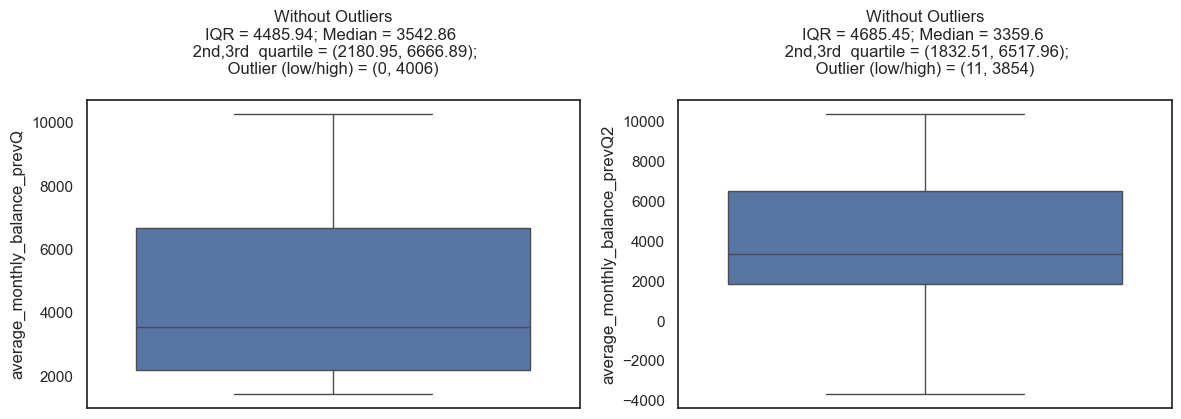

In [96]:
UVA_outlier(data, previous_quarters, include_outlier = False)

In [97]:
# islolating numerical datatypes
numerical = data.select_dtypes(include=['int64','float64','Int64'])[:]
numerical.dtypes

customer_id                         int64
vintage                             int64
age                                 int64
dependents                          Int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
doy_ls_tran                       float64
moy_ls_tran                       float64
dow_ls_tran                       float64
dtype: object

In [98]:
# calculating correlation
correlation = numerical.dropna().corr()
correlation

,customer_id,vintage,age,dependents,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,doy_ls_tran,moy_ls_tran,dow_ls_tran
customer_id,1.000000,-0.011288,0.001397,-0.009737,0.014989,0.012414,0.011372,0.008060,0.004223,-0.004819,0.004870,-0.005906,0.012085,0.011025,-0.006114,-0.005374,0.009665
vintage,-0.011288,1.000000,0.003170,0.005109,-0.007223,-0.008001,-0.010858,-0.003824,-0.004821,-0.000410,-0.004899,-0.007777,-0.008703,-0.010439,-0.000680,-0.001359,-0.009683
age,0.001397,0.003170,1.000000,-0.003809,0.058925,0.062775,0.070903,0.081361,0.023921,0.027678,0.025366,0.027717,0.063120,0.067712,0.010754,0.011970,-0.020895
dependents,-0.009737,0.005109,-0.003809,1.000000,-0.004554,-0.000826,0.000121,0.002584,0.002188,0.022772,0.006784,0.029073,-0.001859,0.000241,0.079740,0.077978,-0.001702
current_balance,0.014989,-0.007223,0.058925,-0.004554,1.000000,0.809257,0.857204,0.584156,0.053329,0.101495,0.075149,0.151771,0.940234,0.812295,0.035242,0.033127,-0.000315
previous_month_end_balance,0.012414,-0.008001,0.062775,-0.000826,0.809257,1.000000,0.908053,0.661439,0.051080,0.195149,0.100379,0.192376,0.910206,0.912269,0.024130,0.023485,0.002033
average_monthly_balance_prevQ,0.011372,-0.010858,0.070903,0.000121,0.857204,0.908053,1.000000,0.731953,0.051294,0.138967,0.091491,0.187226,0.920943,0.983797,0.021103,0.020949,0.000647
average_monthly_balance_prevQ2,0.008060,-0.003824,0.081361,0.002584,0.584156,0.661439,0.731953,1.000000,0.085542,0.127557,0.098455,0.162203,0.642531,0.701780,0.010306,0.009123,-0.002463
current_month_credit,0.004223,-0.004821,0.023921,0.002188,0.053329,0.051080,0.051294,0.085542,1.000000,0.165102,0.941455,0.116125,0.055339,0.055020,0.031828,0.030267,0.000752
previous_month_credit,-0.004819,-0.000410,0.027678,0.022772,0.101495,0.195149,0.138967,0.127557,0.165102,1.000000,0.160198,0.749628,0.141613,0.178147,0.070141,0.066691,-0.006657


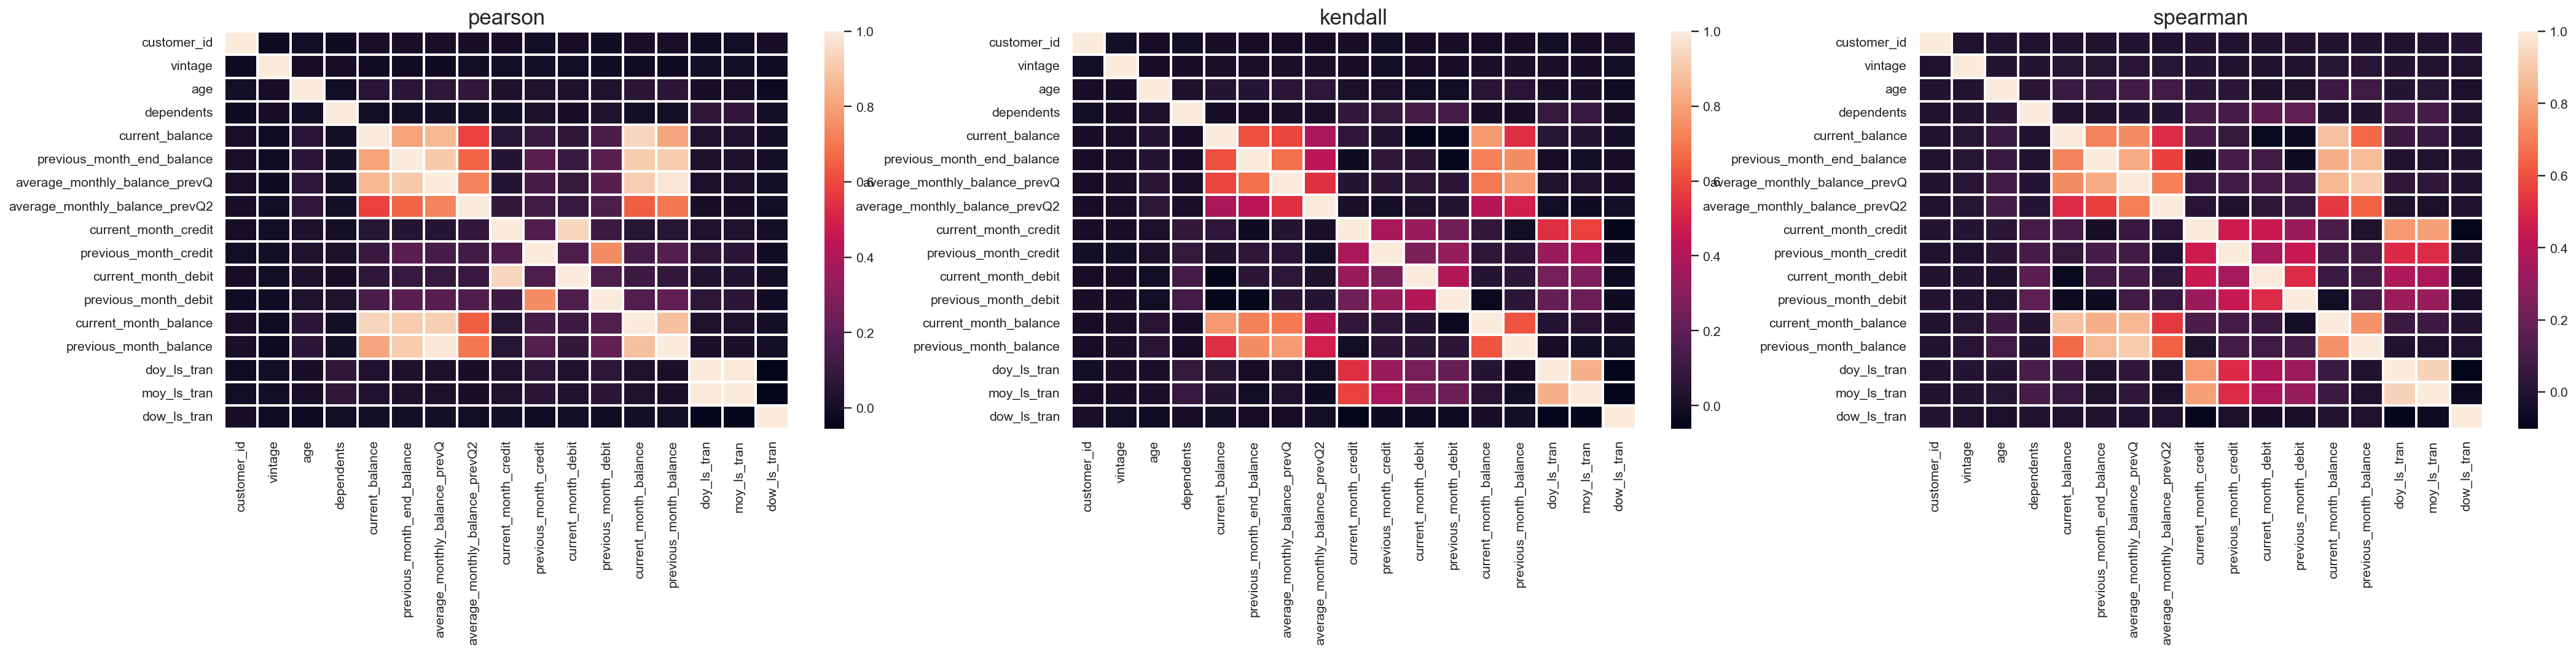

In [99]:
# plotting heatmap usill all method for all numerical variables
plt.figure(figsize=(36,6), dpi=140)
for j, i in enumerate(['pearson','kendall','spearman']):
    plt.subplot(1,3,j+1)
    correlation = numerical.dropna().corr(method=i)
    sns.heatmap(correlation, linewidth = 2)
    plt.title(i, fontsize=18)

In [100]:
# extracting transaction information of current and previous months
var=[]
var.extend(previous_month)
var.extend(current_month)
var.extend(previous_quarters)

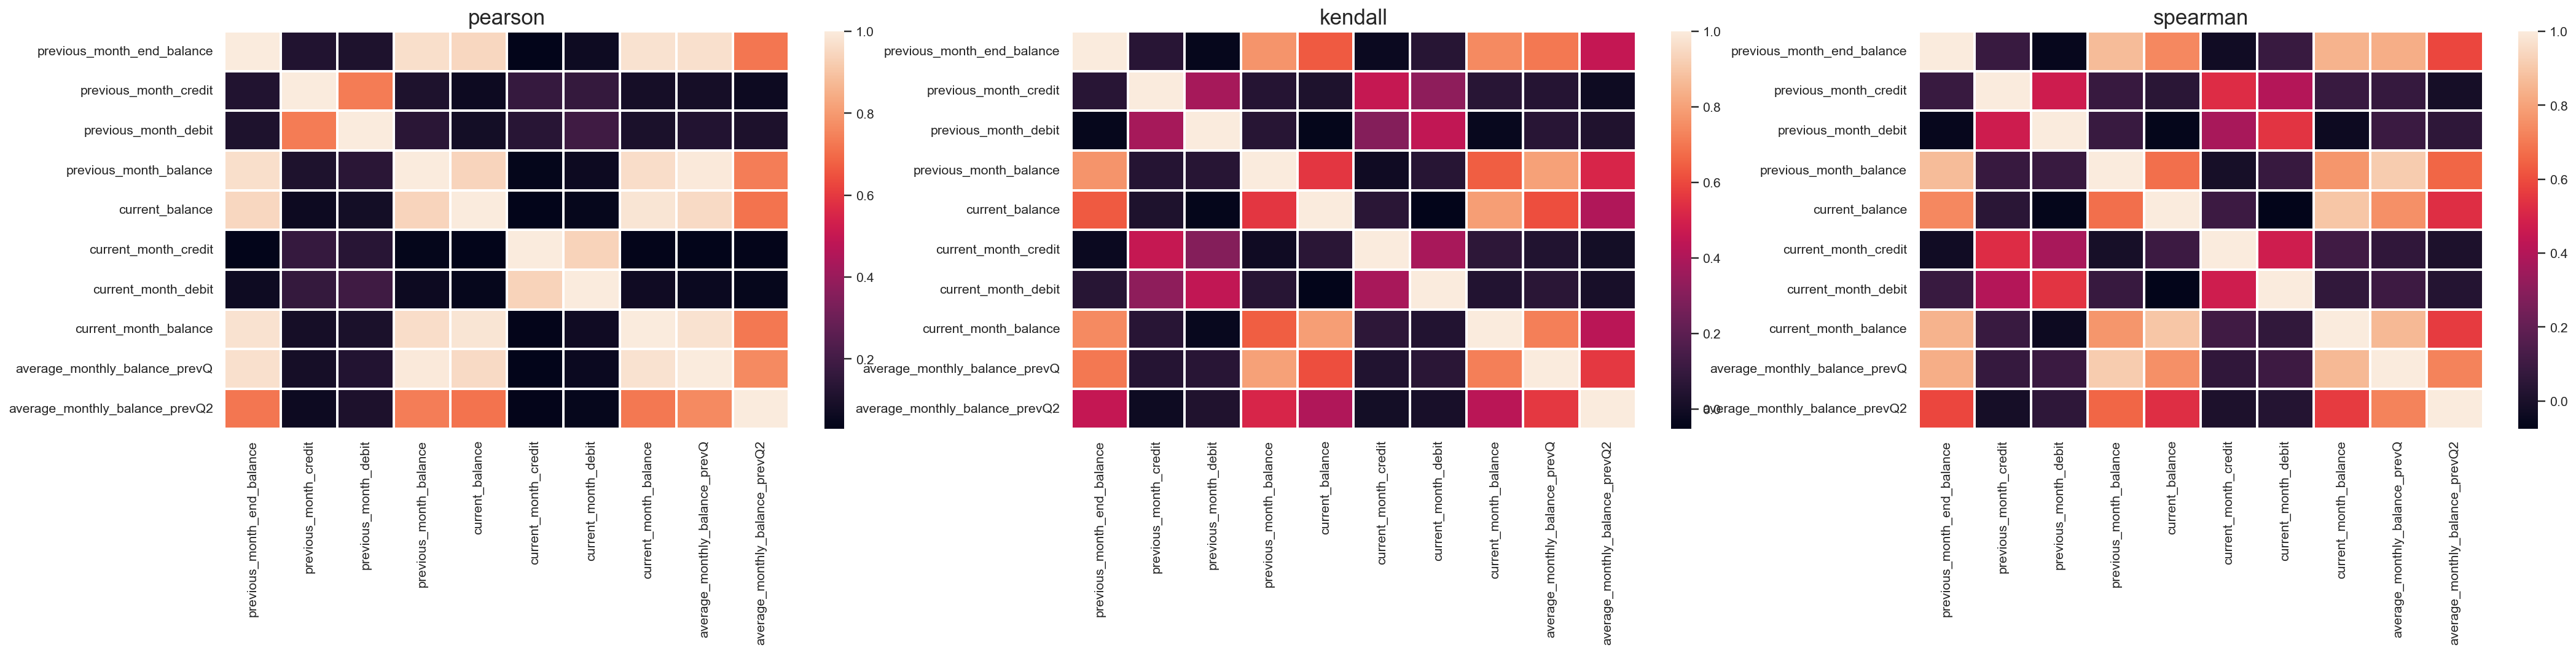

In [101]:
# plottiing heatmap usill all methods for all transaction variables
plt.figure(figsize=(36,6), dpi=140)
for j, i in enumerate(['pearson','kendall','spearman']):
    plt.subplot(1,3,j+1)
    correlation = numerical[var].corr(method=i)
    sns.heatmap(correlation, linewidth = 2)
    plt.title(i, fontsize=18)

In [102]:
# Grouping variables
transactions = ['current_month_credit','current_month_debit','previous_month_credit','previous_month_debit']
balance = ['previous_month_end_balance','previous_month_balance','current_balance','current_month_balance']

<Figure size 896x672 with 0 Axes>

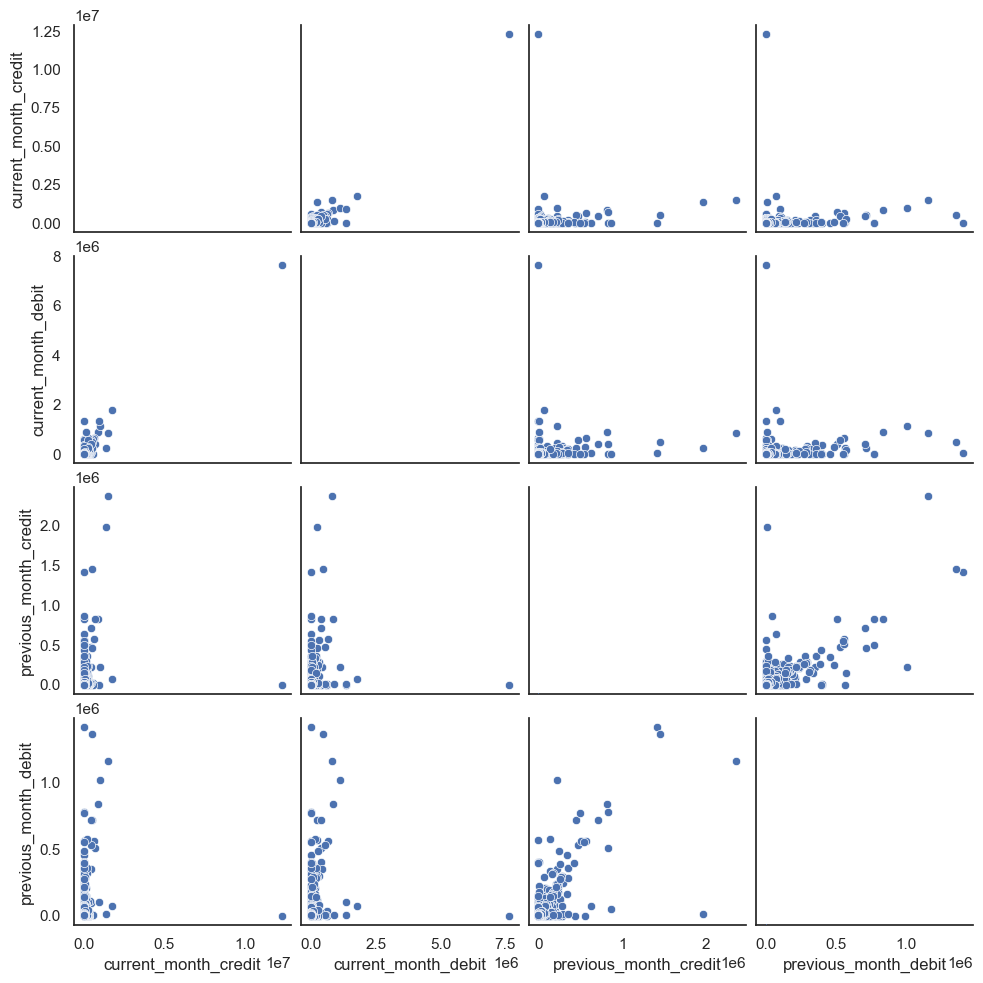

In [103]:
# scatter plot for transactional variables
plt.figure(dpi=140)
sns.pairplot(numerical[transactions])
plt.show()

---
#taking log of every value to negate outliers
for column in var :
    mini=1
    if numerical[column].min()<0:
        mini = abs(numerical[column].min()) + 1

numerical[column] = [i+mini for i in numerical[column]]
numerical[column] = numerical[column].map(lambda x : np.log(x))
---


In [104]:

for column in var:
    min_val = numerical[column].min()
    if min_val <= 0:
        shift = abs(min_val) + 1
    else:
        shift = 0
    
    numerical[column] = numerical[column] + shift
    numerical[column] = numerical[column].apply(lambda x: np.log(x))



<Figure size 896x672 with 0 Axes>

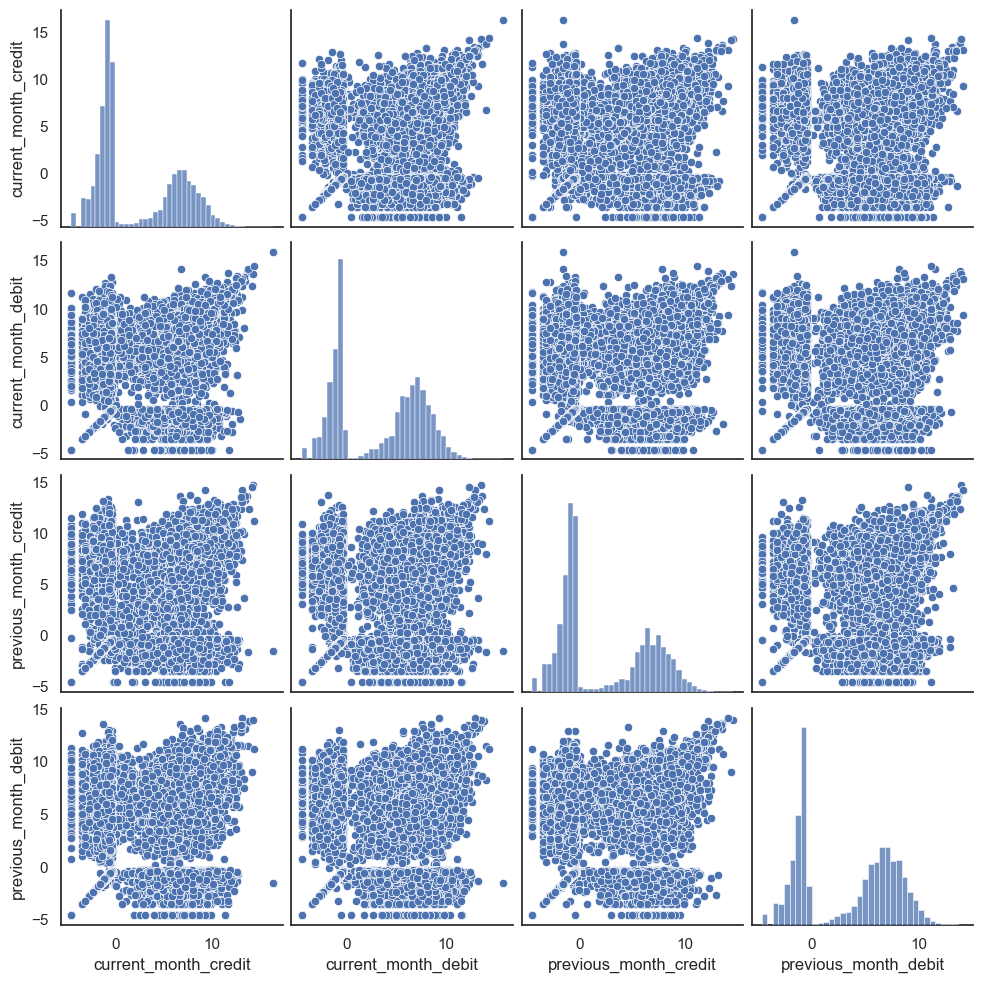

In [105]:
# scatter plot for transactional variables
plt.figure(dpi=140)
sns.pairplot(numerical[transactions])


<Figure size 896x672 with 0 Axes>

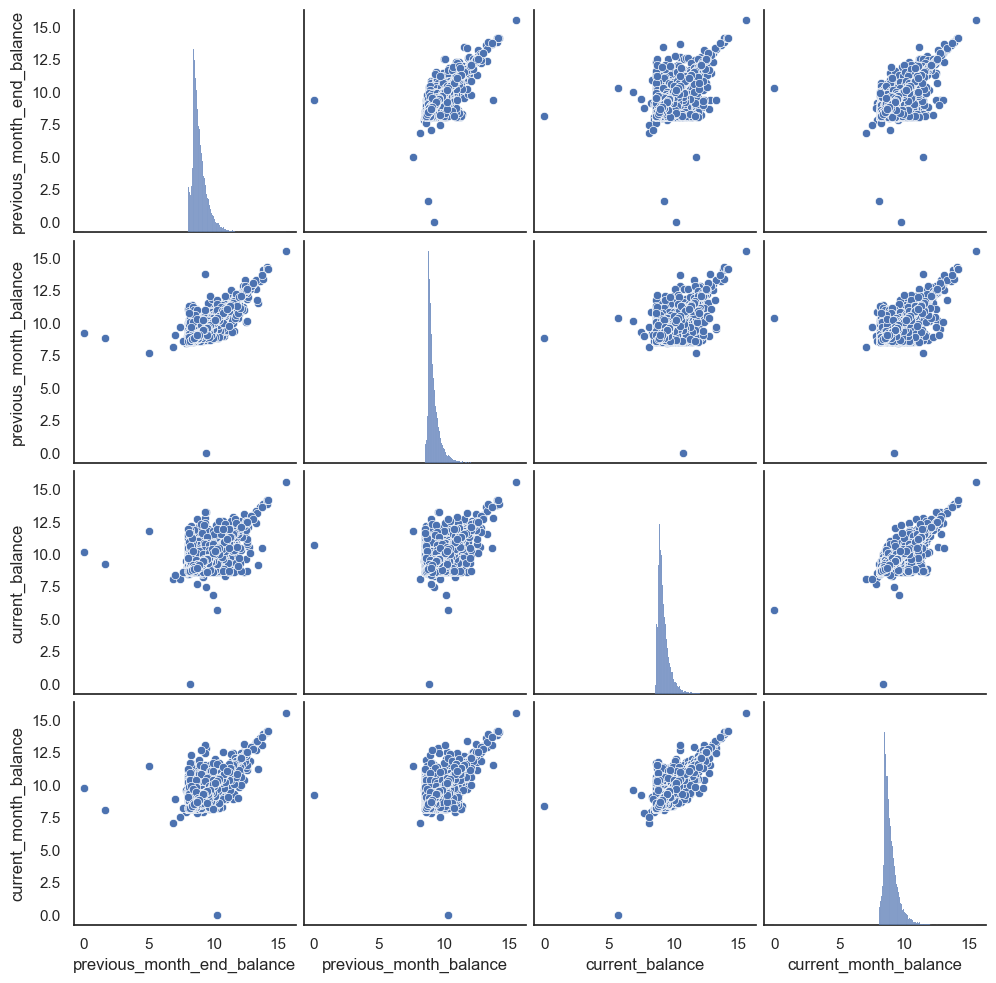

In [106]:
# balance variables
plt.figure(dpi=140)
sns.pairplot(numerical[balance])

<Axes: xlabel='average_monthly_balance_prevQ', ylabel='average_monthly_balance_prevQ2'>

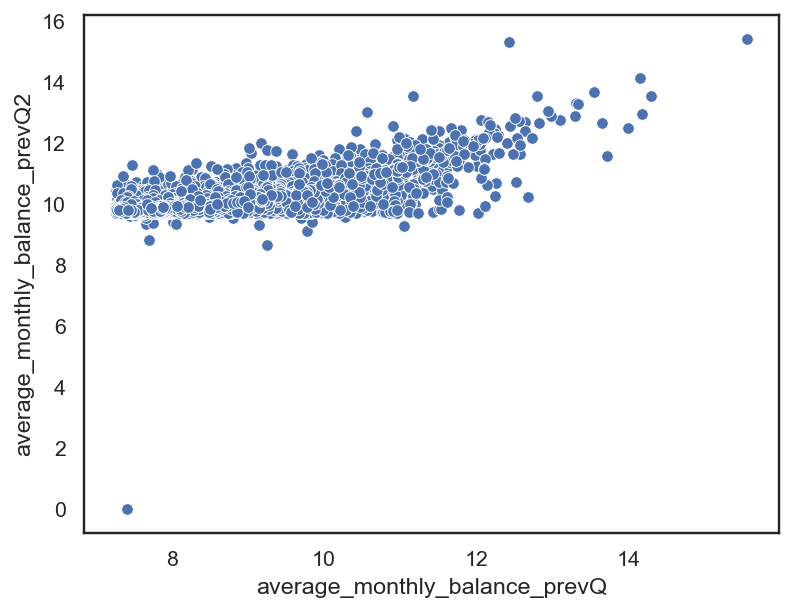

In [107]:
# previous quarters
plt.figure(dpi=140)
sns.scatterplot(data=numerical, x='average_monthly_balance_prevQ', y='average_monthly_balance_prevQ2')

<Axes: xlabel='average_monthly_balance_prevQ', ylabel='average_monthly_balance_prevQ2'>

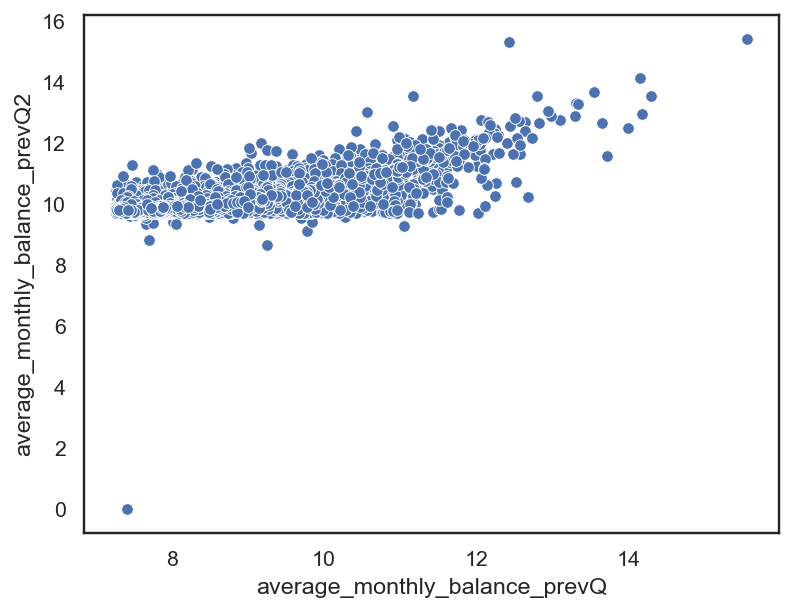

In [108]:
# previous quarters
plt.figure(dpi=140)
sns.scatterplot(x=numerical['average_monthly_balance_prevQ'], y=numerical['average_monthly_balance_prevQ2'])

In [109]:
def TwoSampZ(X1 ,X2, sigma1, sigma2, N1, N2):
    '''
    takes mean, standard deviation, and number of observation and returns p-value calculated for 2-sampled Z-Test
    '''
    from numpy import sqrt, abs, round
    from scipy.stats import norm
    ovr_sigma = sqrt(sigma1**2/N1 + sigma2**2/N2)
    z = (X1 - X2)/ovr_sigma
    pval = 2*(1 - norm.cdf(abs(z)))
    return pval

In [110]:
def TwoSampT(X1, X2, std1, std2, n1, n2):
    '''
    takes mean, standard deviation, and number of observation and returns p-values calculated for 2-sample T-test
    '''
    from numpy import sqrt, abs, round
    from scipy.stats import t as t_dist
    ovr_std = sqrt(std1**2/n1 + std2**2)
    t = (X1 - X2)/ovr_std
    df = n1+n2-2
    pval = 2*(1 - t_dist.cdf(abs(t),df))
    return pval    

In [111]:
def Bivariate_cont_cat(data, cont, cat, category):
    # creatinng description
    X1 = data[cont][data[cat]==category][:]
    X2 = data[cont][~(data[cat]==category)][:]

    # calculatinng descriptives
    n1, n2 = X1.shape[0], X2.shape[0]
    m1, m2 = X1.mean(), X2.mean()
    std1, std2 = X1.std(), X2.std()

    #calculating p-values
    t_p_val = TwoSampT(m1, m2, std1, std2, n1, n2)
    z_p_val = TwoSampZ(m1, m2, std1, std2, n1, n2)

    #table
    table = pd.pivot_table(data=data, values=cont, columns=cat, aggfunc = np.mean)

    # plotting
    plt.figure(figsize = (15,6), dpi=140)

    #barplot
    plt.subplot(1,2,1)
    sns.barplot(x=[str(category),'not {}'.format(category)], y=[m1,m2], palette='deep')
    plt.ylabel('mean {}'.format(cont))
    plt.xlabel(cat)
    plt.title('t-test p-value = {} \n z-test p-value = {}\n {}'.format(t_p_val,z_p_val, table))

    #boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=cat, y=cont, data=data, palette='deep')
    plt.title('categorical boxplot')

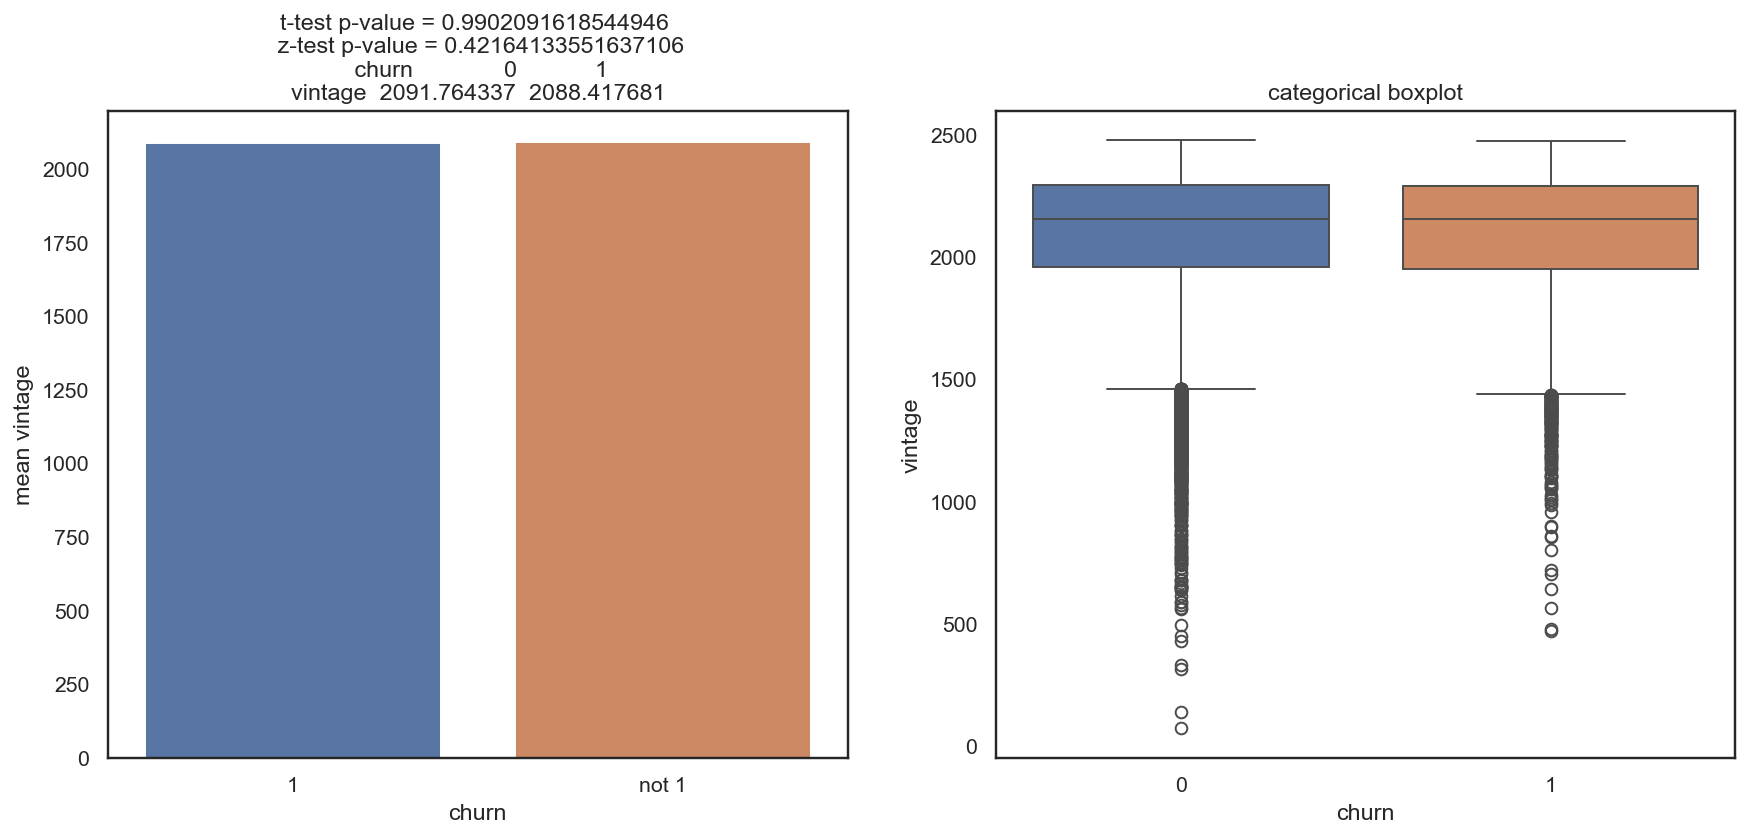

In [112]:
Bivariate_cont_cat(data, 'vintage', 'churn', 1)

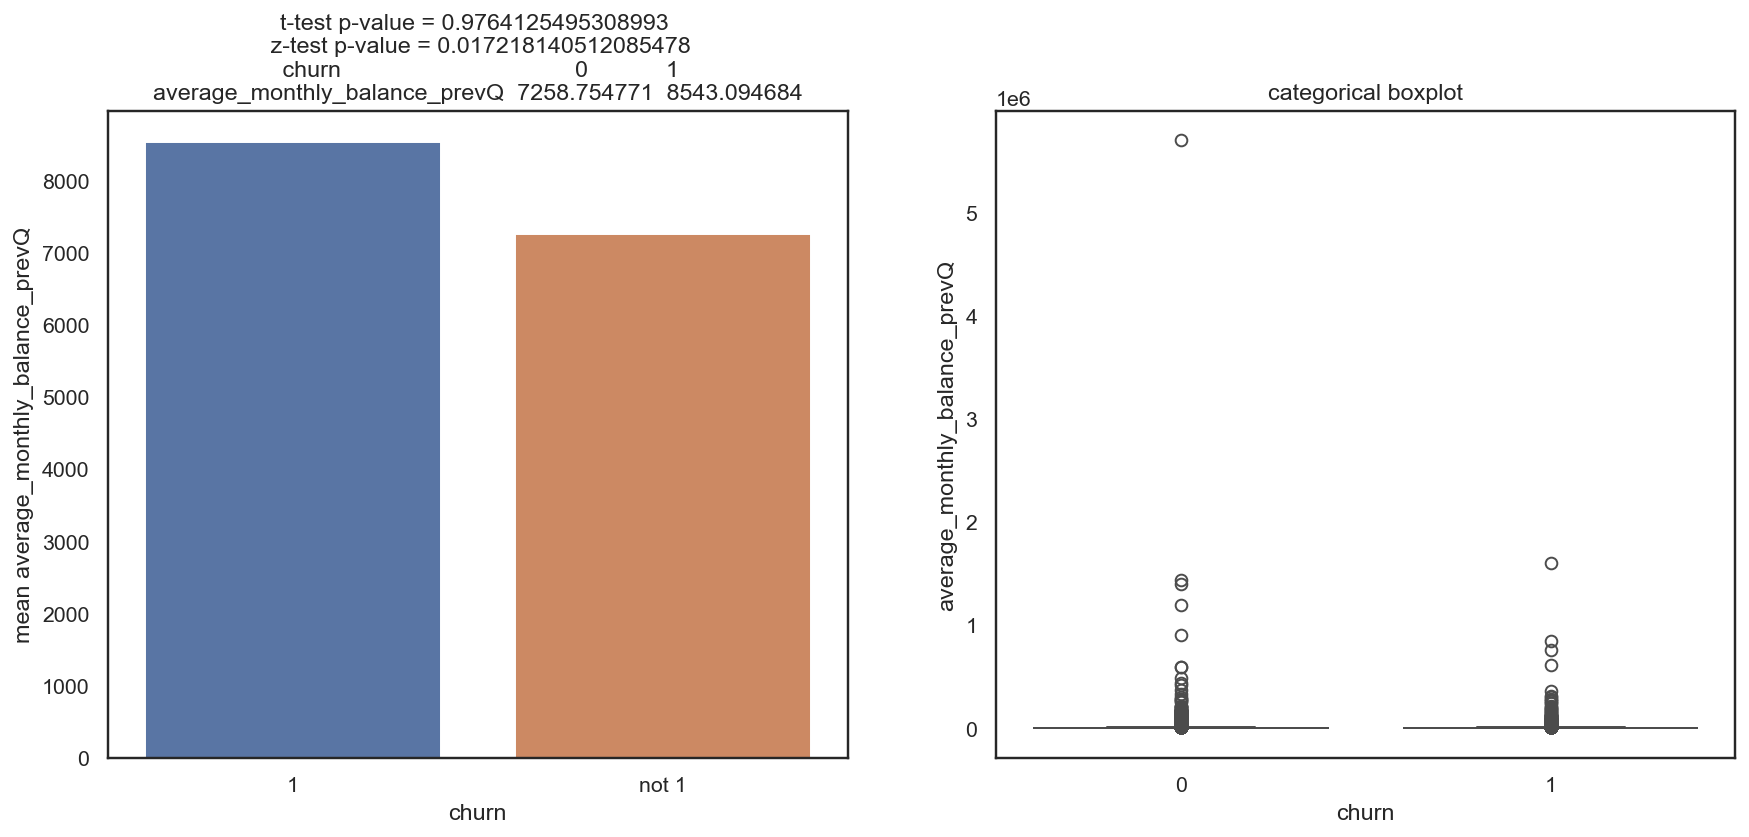

In [113]:
Bivariate_cont_cat(data, 'average_monthly_balance_prevQ', 'churn', 1)

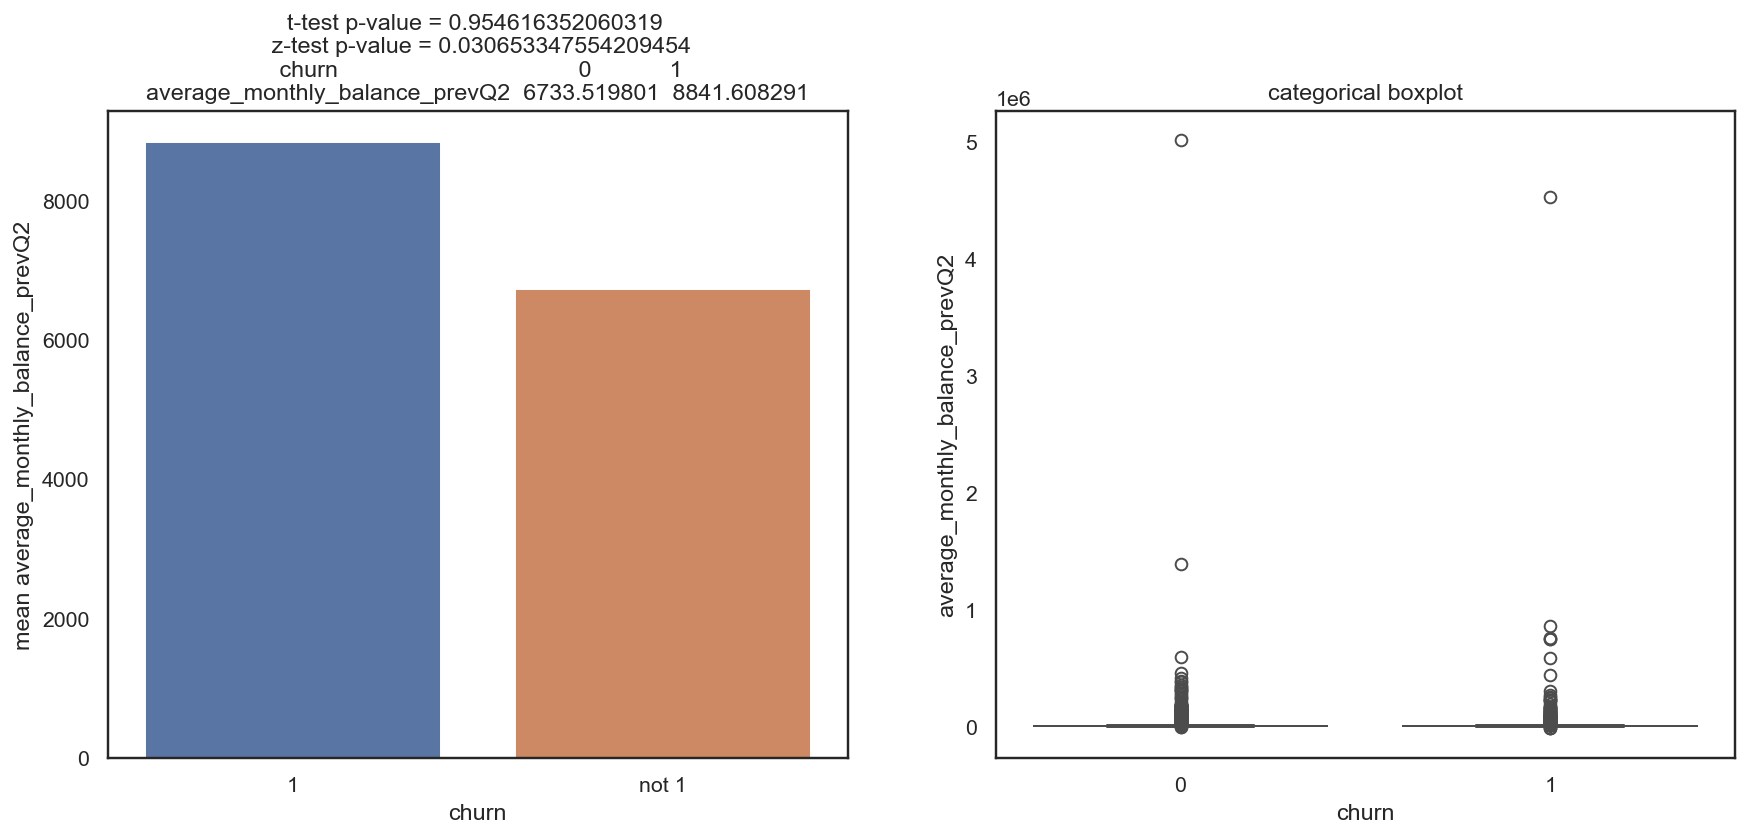

In [114]:
Bivariate_cont_cat(data, 'average_monthly_balance_prevQ2', 'churn', 1)

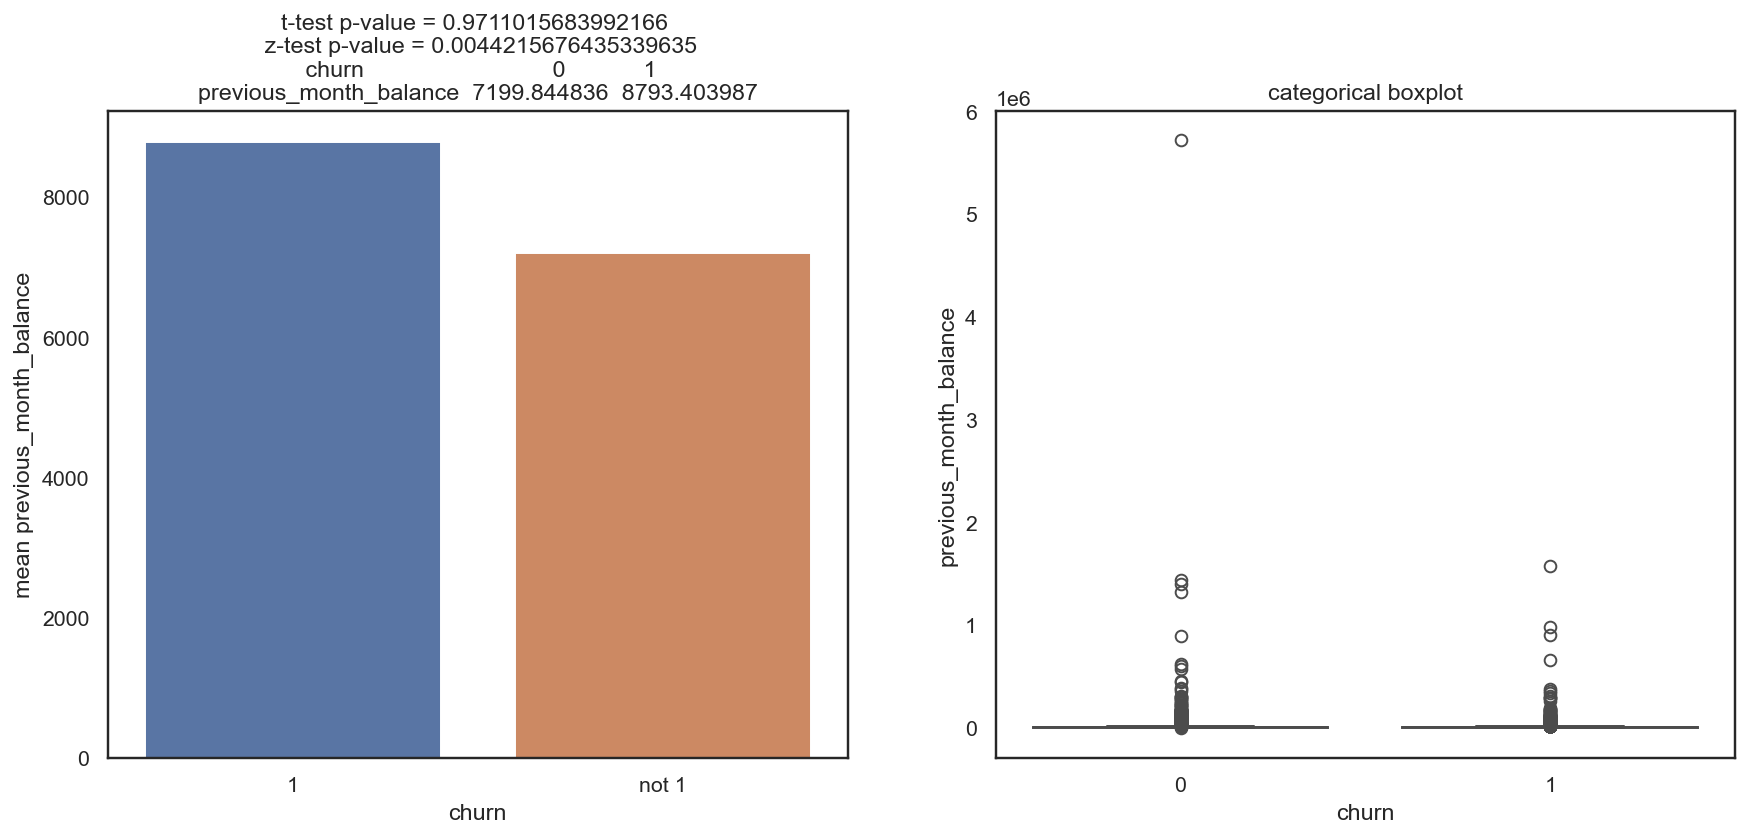

In [115]:
Bivariate_cont_cat(data, 'previous_month_balance', 'churn', 1)

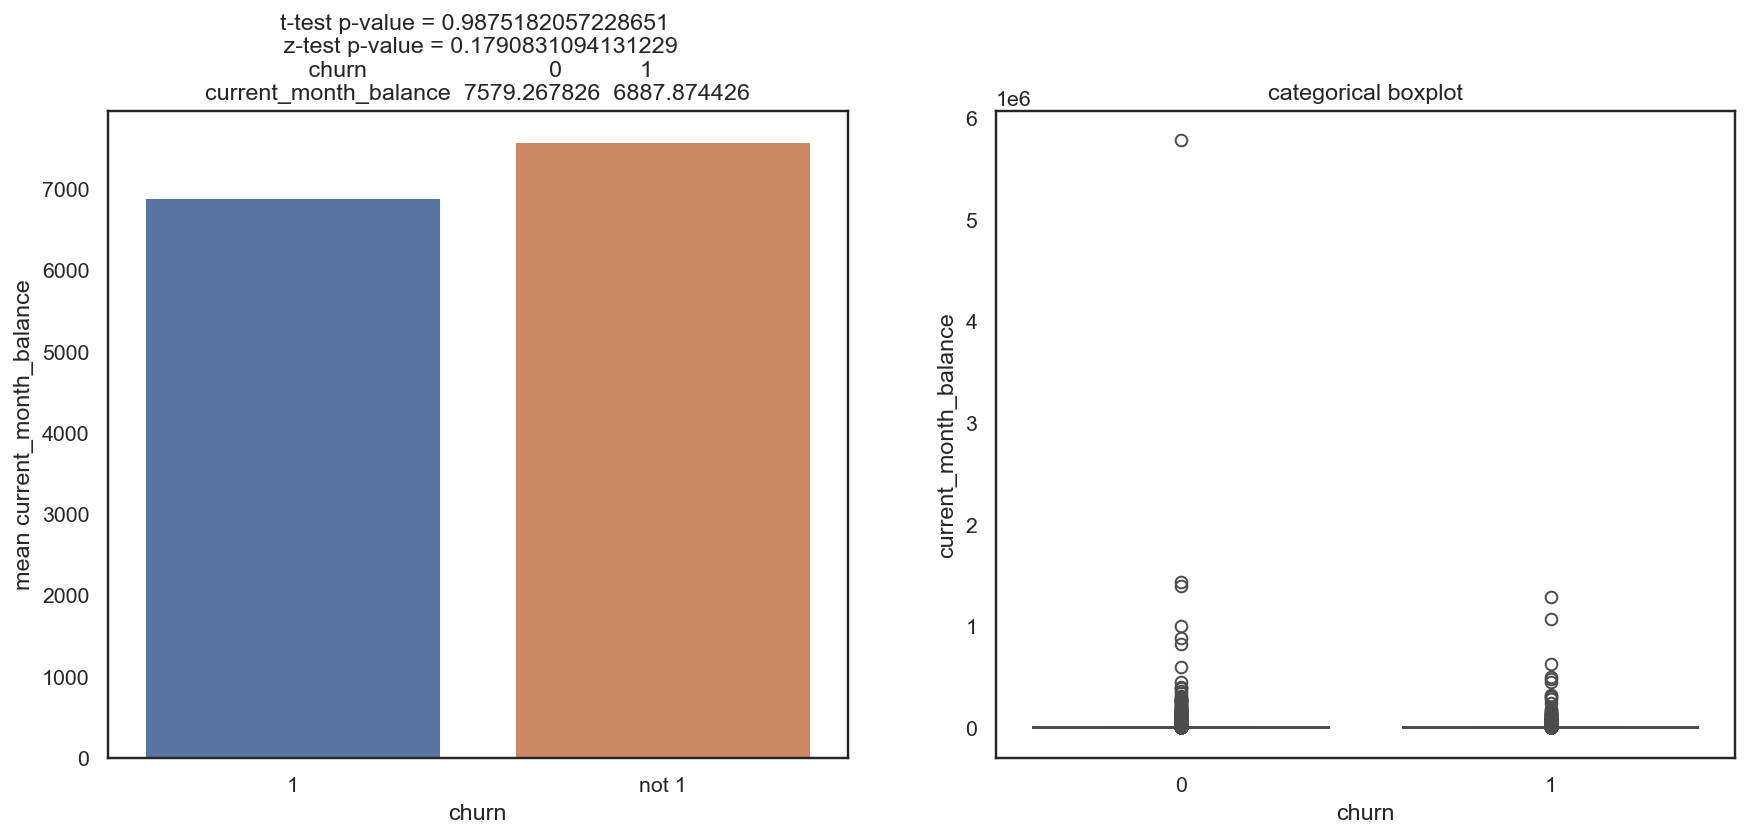

In [116]:
Bivariate_cont_cat(data, 'current_month_balance', 'churn', 1)

In [117]:
# Extracting drop of balance in previous and current month
difference = data[['churn','previous_month_balance','current_month_balance']][:]
difference['bal_diff'] = difference['current_month_balance']-difference['previous_month_balance']

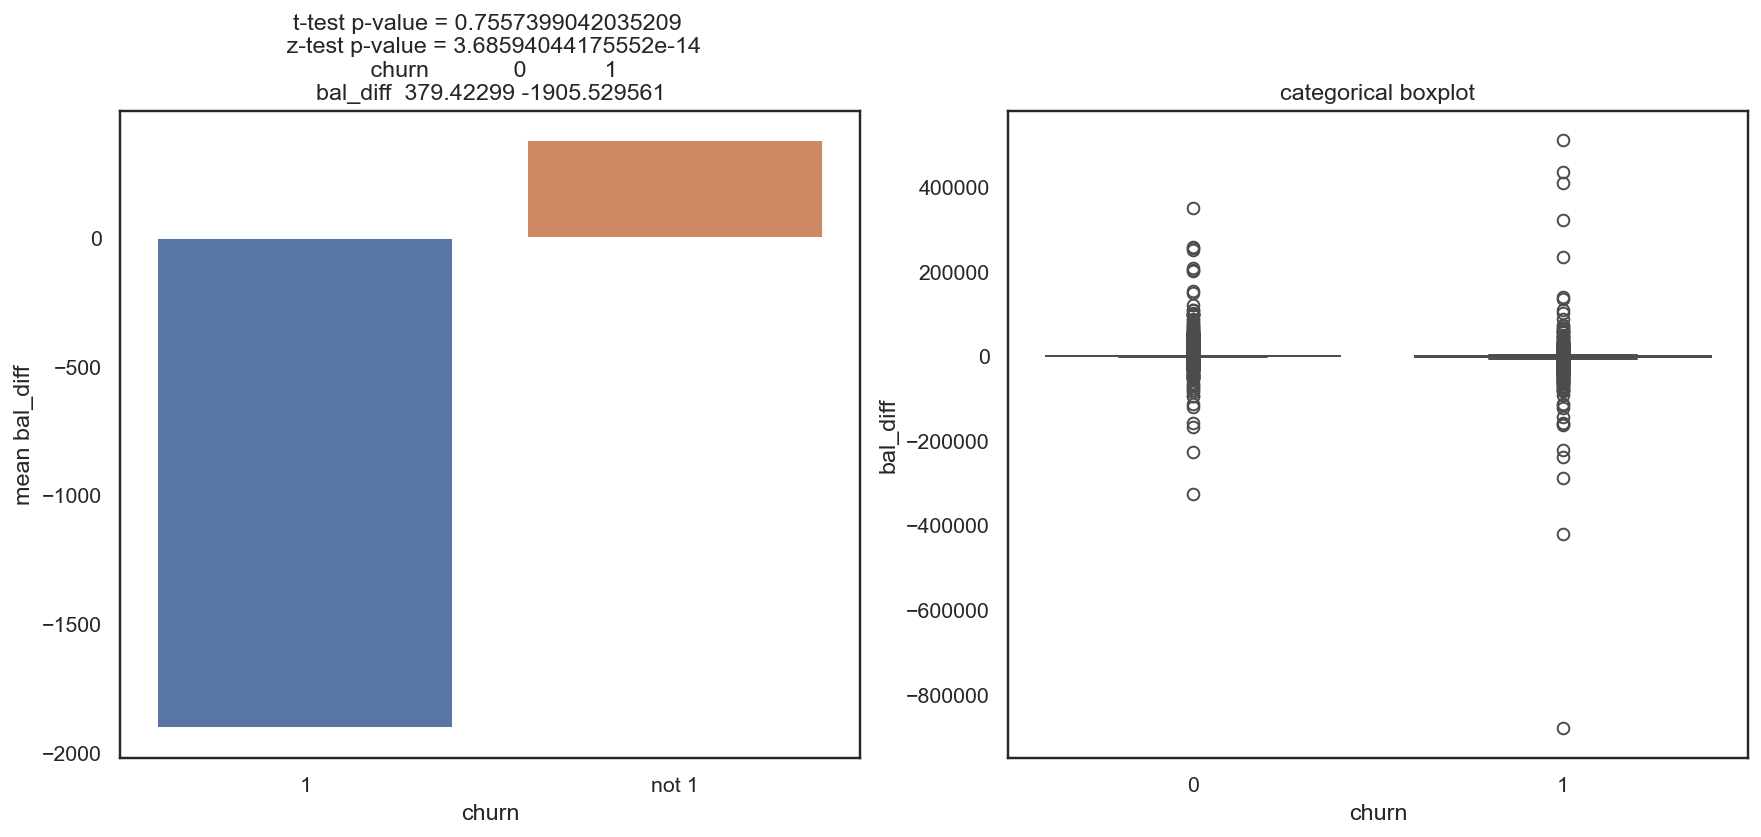

In [118]:
Bivariate_cont_cat(difference, 'bal_diff', 'churn', 1)

In [119]:
d = data[['churn', 'gender']]

In [120]:
t = pd.crosstab(d['churn'], d['gender'])

In [121]:
t

gender,Female,Male
churn,,
0,9324,13379
1,1985,3169


In [122]:
from scipy.stats import chi2_contingency

In [123]:
chi2_contingency(t)

Chi2ContingencyResult(statistic=11.270738823296812, pvalue=0.0007873838498074115, dof=1, expected_freq=array([[ 9216.65028539, 13486.34971461],
       [ 2092.34971461,  3061.65028539]]))

In [124]:
pd.crosstab(d['gender'], d['churn'], normalize='index')

churn,0,1
gender,,
Female,0.824476,0.175524
Male,0.808496,0.191504


In [125]:
data.isna().mean()*100

customer_id                        0.000000
vintage                            0.000000
age                                0.000000
gender                             1.849764
dependents                         8.678035
occupation                         0.281869
city                               2.829258
customer_nw_category               0.000000
branch_code                        0.000000
current_balance                    0.000000
previous_month_end_balance         0.000000
average_monthly_balance_prevQ      0.000000
average_monthly_balance_prevQ2     0.000000
current_month_credit               0.000000
previous_month_credit              0.000000
current_month_debit                0.000000
previous_month_debit               0.000000
current_month_balance              0.000000
previous_month_balance             0.000000
churn                              0.000000
doy_ls_tran                       11.355789
woy_ls_tran                       11.355789
moy_ls_tran                     

In [126]:
data.dropna(subset=['gender'])

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,doy_ls_tran,woy_ls_tran,moy_ls_tran,dow_ls_tran
0,1,2101,66,Male,0,self_employed,187.0,2,755,1458.71,...,0.20,0.20,0.20,1458.71,1458.71,0,141.0,21,5.0,1.0
1,2,2348,35,Male,0,self_employed,NaN,2,3214,5390.37,...,0.56,5486.27,100.56,6496.78,8787.61,0,305.0,44,11.0,4.0
2,4,2194,31,Male,0,salaried,146.0,2,41,3913.16,...,0.61,6046.73,259.23,5006.28,5070.14,0,NaN,<NA>,NaN,NaN
4,6,1579,42,Male,2,self_employed,1494.0,3,388,927.72,...,714.61,588.62,1538.06,1157.15,1677.16,1,307.0,44,11.0,6.0
5,7,1923,42,Female,0,self_employed,1096.0,2,1666,15202.20,...,0.36,857.50,286.07,15719.44,15349.75,0,305.0,44,11.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,30297,2325,10,Female,0,student,1020.0,2,1207,1076.43,...,0.30,0.30,0.30,1076.43,1076.43,0,295.0,43,10.0,1.0
28378,30298,1537,34,Female,0,self_employed,1046.0,2,223,3844.10,...,2.29,901.00,1014.07,3738.54,3690.32,0,351.0,51,12.0,1.0
28379,30299,2376,47,Male,0,salaried,1096.0,2,588,65511.97,...,3883.06,168.23,71.80,61078.50,57564.24,1,365.0,1,12.0,1.0
28380,30300,1745,50,Male,3,self_employed,1219.0,3,274,1625.55,...,0.20,0.20,0.20,1625.55,1625.55,0,NaN,<NA>,NaN,NaN


In [127]:
def BVA_categorical_plot(data, tar, cat):
    '''
    take data and two  categorical variables,
    calculates the chi significance between the two variables
    and prinnts the result with countplot & crossTab
    '''
    # isolating the variables
    data = data[[cat,tar]][:]

    #forming a crosstab
    table = pd.crosstab(data[tar],data[cat])

    #performing chi2 test
    from scipy.stats import chi2_contingency
    chi, p, dof, expected = chi2_contingency(table)

    #checking whether result are significant
    if p<0.05:
        sig = True
    else:
        sig : False

    # plotting grouped plot
    sns.countplot(x=cat, hue=tar, data=data)
    plt.title(f"p-value = {round(p,8)}\n difference significant? = {sig}\n")

    # plotting percent stacked bar plot
    ax1 = pd.crosstab(data[cat], data[tar], normalize='index')
    ax1.plot(kind='bar', stacked='True', title=str(ax1))
    

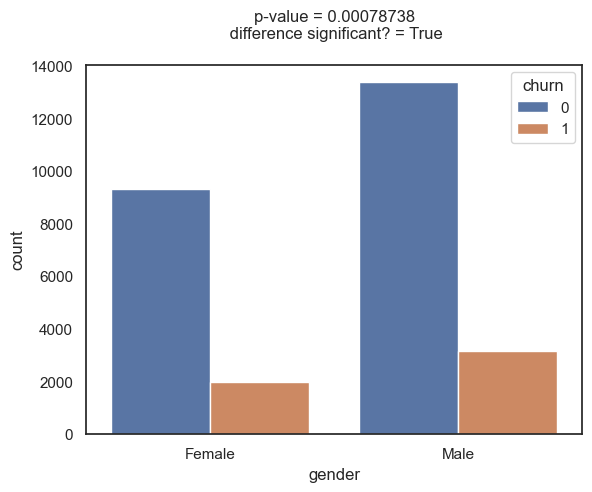

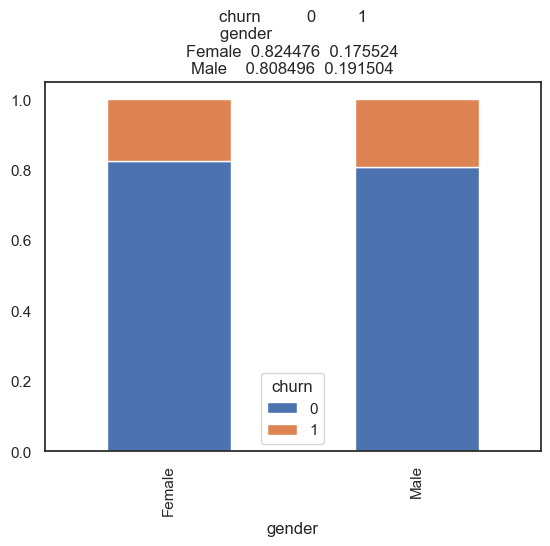

In [128]:
BVA_categorical_plot(data, 'churn', 'gender')

In [129]:
churn = data[['churn','age']][:]

In [130]:
def age_group(x):
    if x >= 80:
        return 'very old'
    elif x < 80 & x >=60:
        return 'senior citizen'
    elif x < 60 & x >=18:
        return 'adult'
    else:
        return 'young'

In [131]:
churn['age_group'] = churn['age'].apply(lambda x : age_group(x))

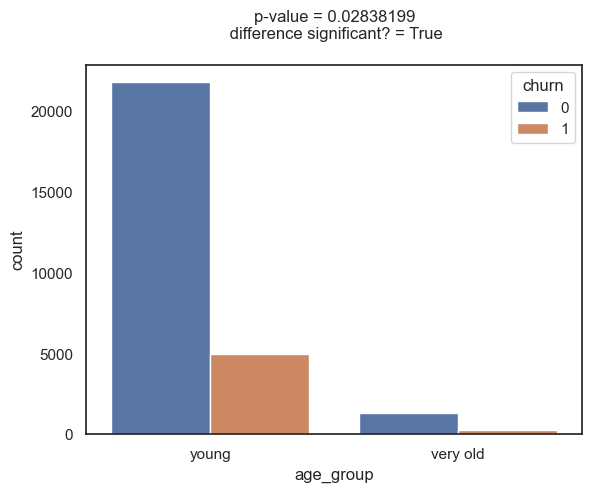

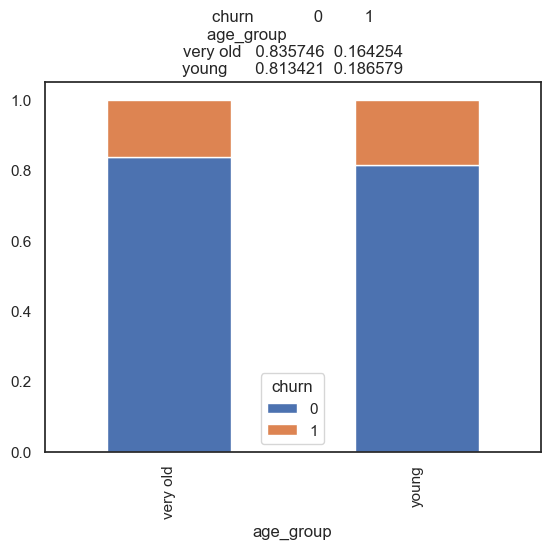

In [132]:
BVA_categorical_plot(churn, 'churn', 'age_group')

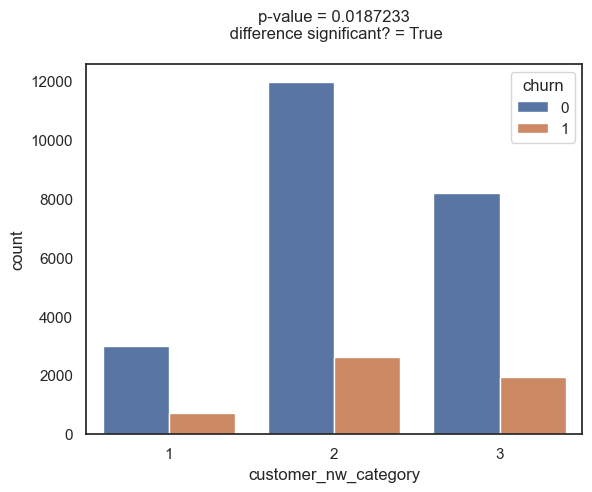

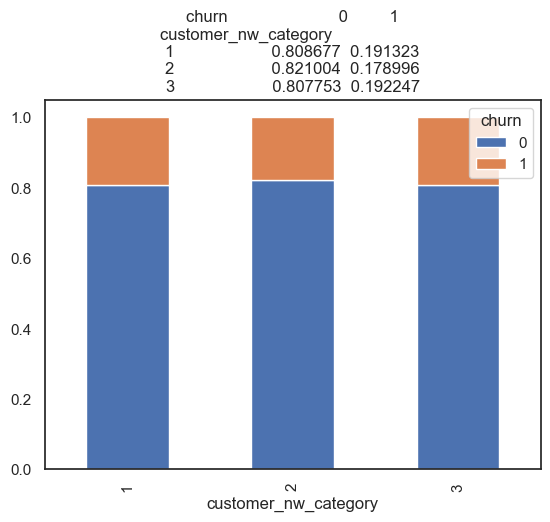

In [133]:
BVA_categorical_plot(data, 'churn', 'customer_nw_category')

In [134]:
dependents = data[['churn','dependents']][:]
dependents.dropna(inplace=True)

In [135]:
def family_group(x):
    if x == 0:
        return 'single'
    elif x >= 1 & x <= 3:
        return 'small family'
    elif x >= 4 & x <= 9:
        return 'large family'
    else:
        return 'joint family'

In [136]:
dependents['dep_group'] = dependents['dependents'].apply(lambda x: family_group(x))

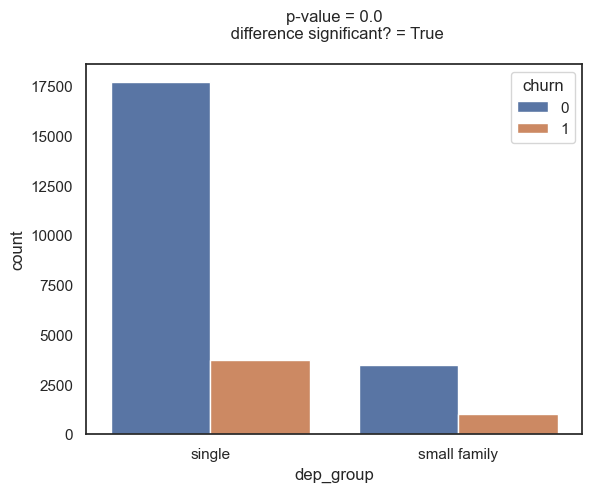

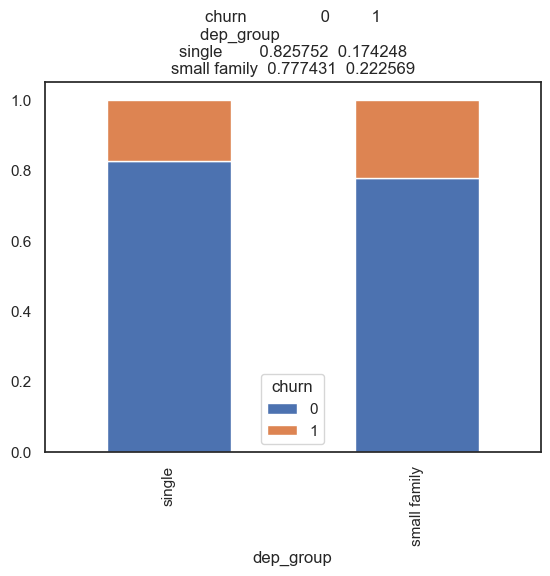

In [137]:
BVA_categorical_plot(dependents, 'churn', 'dep_group')

In [138]:
# segregating customers whose last transaction was more than 6 months ago
transaction = data[['churn','moy_ls_tran']][:]
transaction['moy_ls_tran'] = transaction['moy_ls_tran'].map(lambda x: 'more than 6 months ago' if x<7 else 'within 6 months')

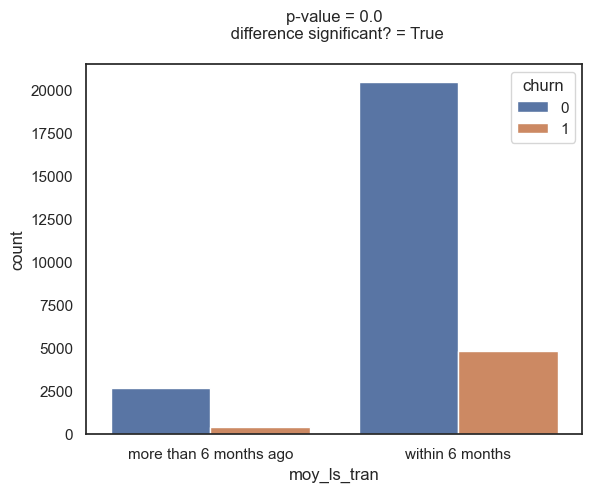

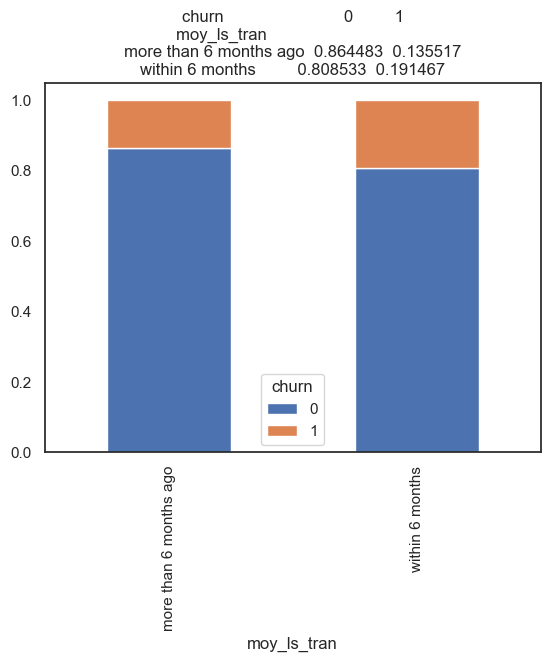

In [139]:
BVA_categorical_plot(transaction, 'churn', 'moy_ls_tran')

In [140]:
# getting city codes which have less than 280 (1%) of accounts
tmp = data['city'].value_counts()
cities = tmp[tmp<280].index

In [141]:
churn_acc = data[['churn','city']][:]
churn_acc['city_cat'] = None

In [142]:
churn_acc.loc[churn_acc['city'].isin(cities[:]), 'city_cat'] = 'low accounts'
churn_acc.loc[~churn_acc['city'].isin(cities[:]), 'city_cat'] = 'high accounts'

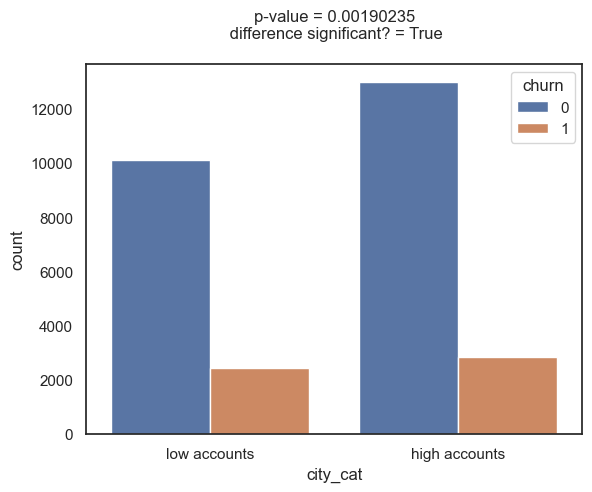

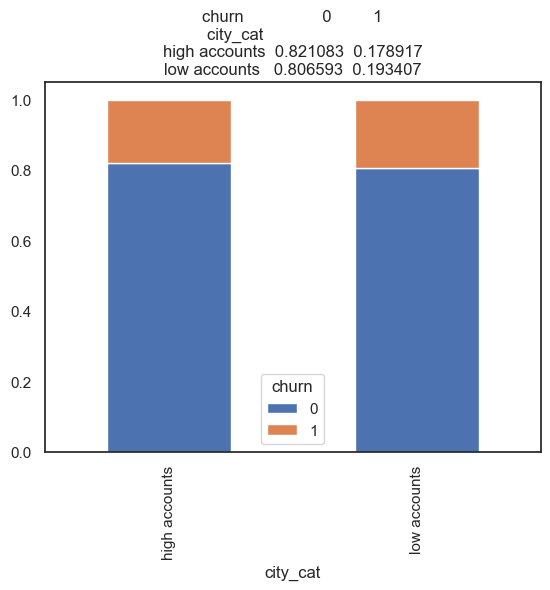

In [143]:
BVA_categorical_plot(churn_acc, 'churn', 'city_cat')

In [144]:
# getting branch codes with more than 0.5% of total accounts
tmp = data['branch_code'].value_counts()[:]
branch = tmp[tmp<140].index

In [145]:
#making two segments
churn_acc = data[['churn','branch_code']][:]
churn_acc['branch_cat'] = None

In [146]:
churn_acc.loc[churn_acc['branch_code'].isin(branch[:]), 'branch_cat'] = 'low accounts'
churn_acc.loc[~churn_acc['branch_code'].isin(branch[:]), 'branch_cat'] = 'high accounts'

UnboundLocalError: cannot access local variable 'sig' where it is not associated with a value

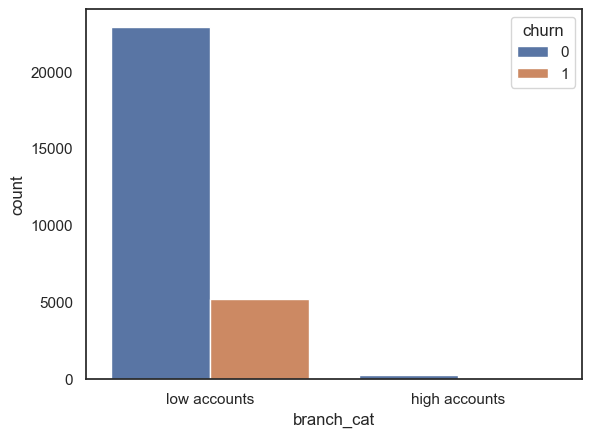

In [147]:
BVA_categorical_plot(churn_acc, 'churn', 'branch_cat')

In [148]:
# isolating rows with missing gender
miss_gender = data[:]
miss_gender.loc[:, 'missing_gender'] = 'not_missing'
miss_gender.loc[~miss_gender['gender'].isin(['Male','Female']), 'missing_gender'] = 'missing value'

/tmp/ipykernel_122347/64145619.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miss_gender.loc[:, 'missing_gender'] = 'not_missing'

UnboundLocalError: cannot access local variable 'sig' where it is not associated with a value

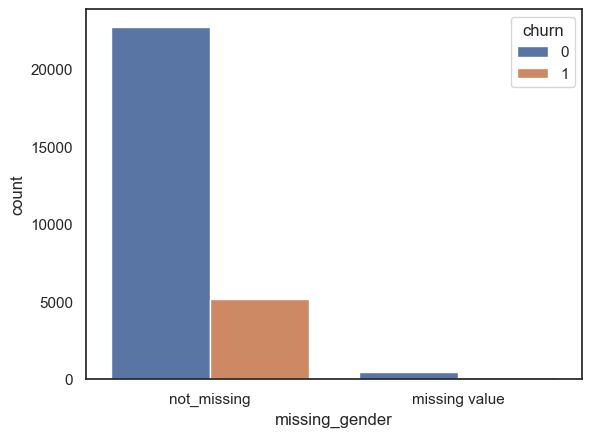

In [149]:
BVA_categorical_plot(miss_gender, 'churn', 'missing_gender')

In [150]:
# isolating rows with missing gender
miss_dependents = data[:]
miss_dependents['missing_dependents'] = 'not_missing'
miss_dependents.loc[~miss_dependents['dependents'].isin([0, 2, 3, 1, 7, 4, 6, 5, 9, 52, 36,50,8,25,32]),
                                                                'missing_dependents'] = 'missing value'

/tmp/ipykernel_122347/3816559365.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miss_dependents['missing_dependents'] = 'not_missing'

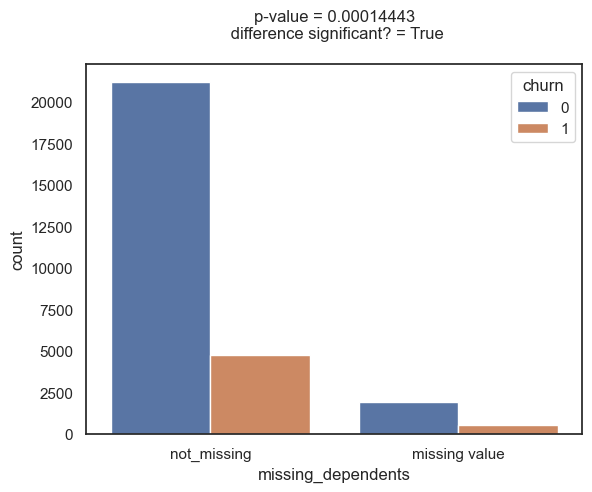

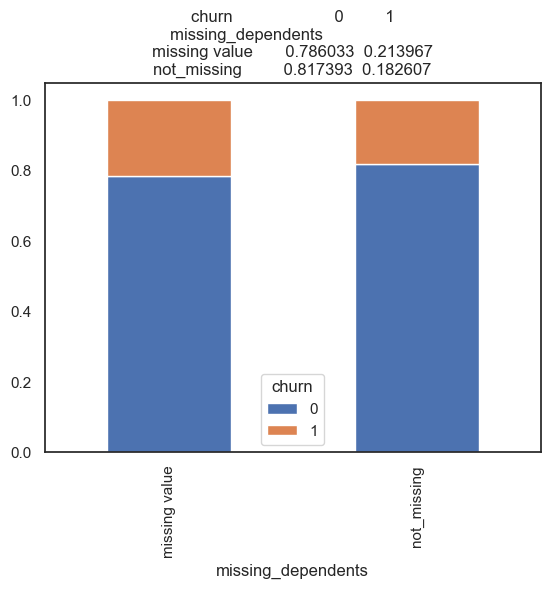

In [151]:
BVA_categorical_plot(miss_dependents, 'churn', 'missing_dependents')

In [152]:
# isolating rows with missing gender
miss_occupation = data[:]
miss_occupation['missing_occupation'] = 'not_missing'
miss_occupation.loc[~miss_occupation['occupation'].isin(['self_employed', 'salaried', 'retired', 'student',
                                                    'company']), 'missing_occupation'] = 'missing value'

/tmp/ipykernel_122347/1209663812.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miss_occupation['missing_occupation'] = 'not_missing'

UnboundLocalError: cannot access local variable 'sig' where it is not associated with a value

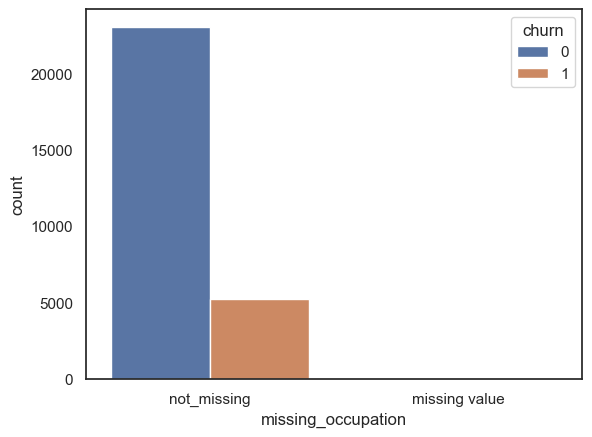

In [153]:
BVA_categorical_plot(miss_occupation, 'churn', 'missing_occupation')

---
for column in var:
    min_val = numerical[column].min()
    if min_val <= 0:
        shift = abs(min_val) + 1
    else:
        shift = 0
    
    numerical[column] = numerical[column] + shift
    numerical[column] = numerical[column].apply(lambda x: np.log(x))
---

In [ ]:
---
# scatter plot for transactional variables
plt.figure(dpi=140)
sns.pairplot(numerical[transactions])
---